Date Range: 08/02/2025 to 01/29/2026
Overall Average Google Spam Rate: 0.00443
Trend: increasing at 0.000142 percentage points per day


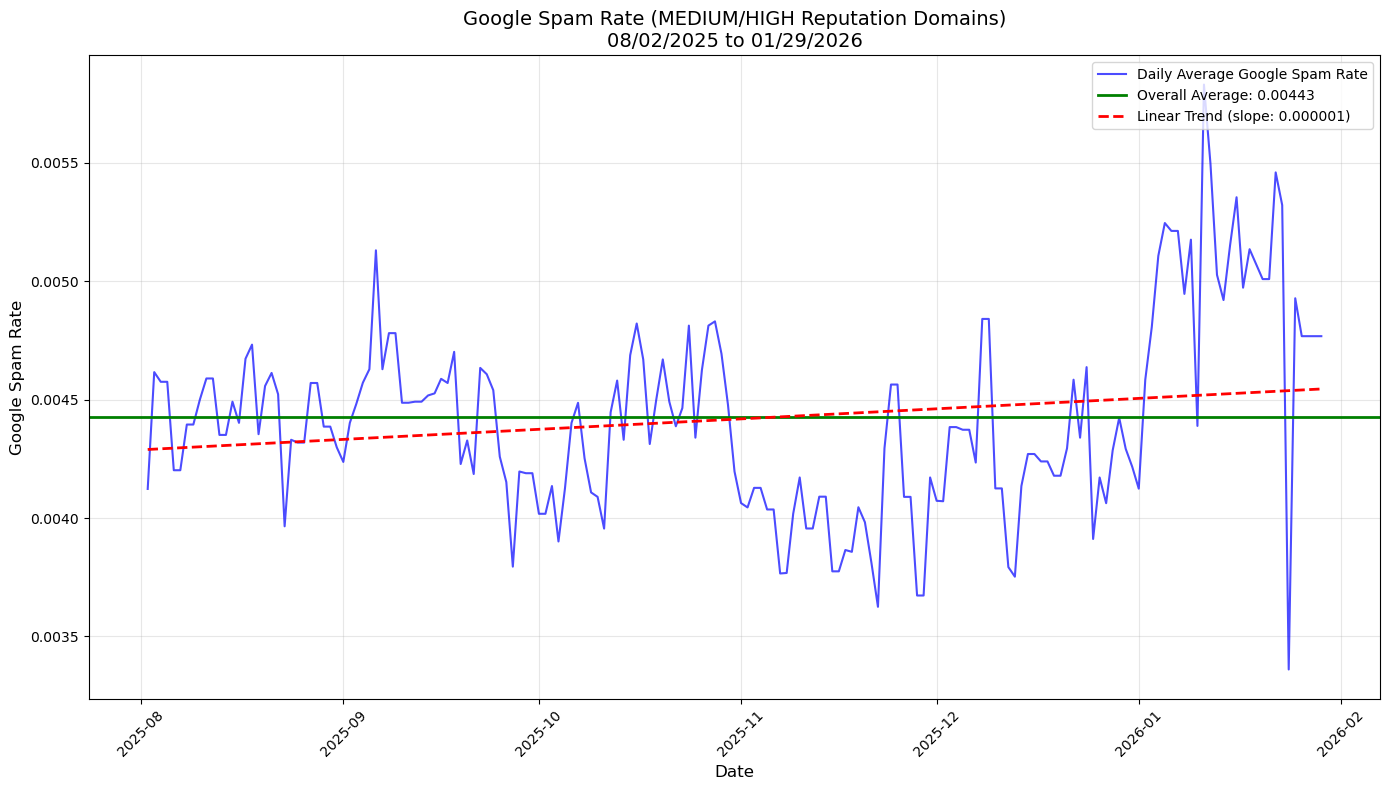


Plot saved as: google_spam_rate_analysis.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Load the dataset
df = pd.read_csv('Postmaster.csv', na_values=['\\N'])

# Ensure the 'date' column is in the correct datetime format
df['date'] = pd.to_datetime(df['date'])

# Filter for domainReputation = MEDIUM or HIGH only
df_filtered = df[df['domainReputation'].isin(['MEDIUM', 'HIGH'])]

# Define the date range (today and past 6 months)
end_date = datetime.now().date()
start_date = end_date - timedelta(days=180)  # approximately 6 months

# Convert to datetime for comparison
end_date = pd.to_datetime(end_date)
start_date = pd.to_datetime(start_date)

print(f"Date Range: {start_date.strftime('%m/%d/%Y')} to {end_date.strftime('%m/%d/%Y')}")

# Filter the DataFrame for the date range
df_filtered = df_filtered[(df_filtered['date'] >= start_date) & (df_filtered['date'] <= end_date)]

# Rename column for clarity
df_filtered = df_filtered.rename(columns={'userReportedSpamRatio': 'Google Spam Rate'})

# Calculate the overall average Spam Rate for the entire period
overall_avg = df_filtered['Google Spam Rate'].mean()
print(f"Overall Average Google Spam Rate: {overall_avg:.5f}")

# Calculate the daily average Spam Rate
daily_avg_spam_rate = df_filtered.groupby('date')['Google Spam Rate'].mean().reset_index()

# Reindex to ensure the data frame covers the entire date range
dates_range = pd.date_range(start=start_date, end=end_date)
daily_avg_spam_rate = daily_avg_spam_rate.set_index('date').reindex(dates_range).reset_index()
daily_avg_spam_rate.columns = ['date', 'Google Spam Rate']

# Forward fill NaN values
daily_avg_spam_rate['Google Spam Rate'] = daily_avg_spam_rate['Google Spam Rate'].ffill()

# Convert dates to numerical format for regression
dates_numeric = np.arange(len(dates_range))

# Compute linear fit
# Handle NaN values in the Spam Rate column
valid_indices = ~np.isnan(daily_avg_spam_rate['Google Spam Rate'])
if sum(valid_indices) > 1:  # Need at least 2 points for linear regression
    dates_numeric_valid = dates_numeric[valid_indices]
    spam_rates_valid = daily_avg_spam_rate['Google Spam Rate'][valid_indices]
    slope, intercept = np.polyfit(dates_numeric_valid, spam_rates_valid, 1)
    fit_line = slope * dates_numeric + intercept
    
    # Calculate trend direction
    trend_direction = "increasing" if slope > 0 else "decreasing"
    daily_change = slope * 100  # Convert to percentage points per day
    print(f"Trend: {trend_direction} at {abs(daily_change):.6f} percentage points per day")
else:
    # If not enough valid data points, don't show the trend line
    fit_line = np.array([np.nan] * len(dates_numeric))

# Plotting the results
plt.figure(figsize=(14, 8))  # Make the figure wider
plt.plot(dates_range, daily_avg_spam_rate['Google Spam Rate'], label='Daily Average Google Spam Rate', color='blue', alpha=0.7)

# Add a horizontal line for the overall average
plt.axhline(y=overall_avg, color='green', linestyle='-', linewidth=2, label=f'Overall Average: {overall_avg:.5f}')

# Only plot the trend line if we have valid data
if not np.all(np.isnan(fit_line)):
    plt.plot(dates_range, fit_line, linestyle='--', color='red', linewidth=2, label=f'Linear Trend (slope: {slope:.6f})')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Google Spam Rate', fontsize=12)
plt.title(f'Google Spam Rate (MEDIUM/HIGH Reputation Domains)\n{start_date.strftime("%m/%d/%Y")} to {end_date.strftime("%m/%d/%Y")}', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig('google_spam_rate_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as: google_spam_rate_analysis.png")

In [ ]:
### Download data from esp_v1>log_gpmt | , rename a1 Sending Domain
### Download Hypercube report:
### https://esp.resultsgeneration.com/Reports/Hypercube?ObjectSelections=DomainGroup%2FGmail&QuickDateSelect=Custom&StartDate=04%2F26%2F2025&EndDate=10%2F26%2F2025&DateGrouping=Daily&DateHandling=Date+Received&PageTitle=&SortColumn=Sent&RowLimit=10000000&Dataset=v2&Query=&MinSentPerGroup=&HAVING=&Show=Sent%2CDelivered%2COpens%2CClicks%2CUnsubscribes%2CRevenue%2CCPM%2CBlocks%2CRPC&Breakdown=Domain+Group%2CSending+Domain&BreakdownListOrder=Domain+Group%2CDomain+Quality%2CSending+Domain%2CSending+Ip%2CClient%2CEmail+List%2CCampaign+Segment%2CCampaign+Sub+Segment%2CDelivery+Type%2CUser+Country%2CList+Country%2CList+Source%2CListSource0%2CListSource1%2CListSource2%2CListSource3%2CListSource4%2CSource+Vertical%2CDelivery+Date%2CAdded+Date%2C3P+Account%2C3P+Account+Country%2C3P+Account+Type%2C3P+Data+Group%2C3P+Manipulator+Type%2CAge+Group%2CAvailable+Data%2CList+Category%2CContact+Group%2CContact+Group+Country%2CNet+Block%2CNet+Name%2CNetName0%2CNetName1%2CReceiving+Domain%2CTrigger+Delay%2CVirtual+List
### Save via excel

In [1]:
# Code Snippet 1 - Updated for new Postmaster.csv format
import pandas as pd

# Read the datasets
esp_data = pd.read_csv('Hypercube.csv')
postmaster_data = pd.read_csv('Postmaster.csv')

# Convert date column in postmaster_data to the same format (MM/DD/YYYY)
postmaster_data['date'] = pd.to_datetime(postmaster_data['date']).dt.strftime('%m/%d/%Y')

# Rename columns to match the expected format in the merge
postmaster_data = postmaster_data.rename(columns={
    'Sending Domain': 'Sending Domain',
    'date': 'Date',
    'userReportedSpamRatio': 'Spam Rate'
})

# Convert 'Spam Rate' to numeric and then increase each non-missing value by 0.000647
postmaster_data['Spam Rate'] = pd.to_numeric(postmaster_data['Spam Rate'], errors='coerce')
postmaster_data['Spam Rate'] = postmaster_data['Spam Rate'].apply(
    lambda x: x + 0.000647 if pd.notnull(x) else x
)

# Convert date column in dataset A to the same format (MM/DD/YYYY)
esp_data['Date'] = pd.to_datetime(esp_data['Date'], format='%m/%d/%Y').dt.strftime('%m/%d/%Y')

# Merge the datasets
merged_data = pd.merge(esp_data, postmaster_data[['Sending Domain', 'Date', 'Spam Rate']], 
                      on=['Sending Domain', 'Date'], how='left')

# Fill missing values with NaN (this step ensures any missing Spam Rate remains as NaN)
merged_data['Spam Rate'].fillna(value=pd.NA, inplace=True)

# Save data to CSV
merged_data.to_csv('data.csv', index=False)


# Code Snippet 2 - Updated to use domain reputation from Postmaster.csv
import pandas as pd

# Read the Postmaster data to get domain reputations
postmaster_data = pd.read_csv('Postmaster.csv')

# Get the most recent date for each domain
postmaster_recent = postmaster_data.sort_values('date').groupby('Sending Domain').last().reset_index()

# Filter the domains with LOW or BAD reputation
low_bad_domains = postmaster_recent[postmaster_recent['domainReputation'].isin(['LOW', 'BAD'])]['Sending Domain'].tolist()

# Add the standard exclusion
standard_exclusion = 'welcome.best-jobs-online.com'
low_bad_domains.append(standard_exclusion)

# Clean data
data = pd.read_csv('data.csv')

# Step 1: Drop any row with Sent < 15000
data_cleaned = data[data['Sent'] >= 15000]

# Step 2: Drop any row with Spam Rate missing
data_cleaned = data_cleaned[data_cleaned['Spam Rate'].notnull()]

# Step 3: Drop any row with Spam Rate > 0.05
data_cleaned = data_cleaned[data_cleaned['Spam Rate'] <= 0.05]

# Step 4: Calculate a new variable for each row that is Open Rate = Opens/Sent
data_cleaned['Open Rate'] = data_cleaned['Opens'] / data_cleaned['Sent']

# Step 5: Calculate a new variable for each row that is Click Rate = Clicks/Sent
data_cleaned['Click Rate'] = data_cleaned['Clicks'] / data_cleaned['Sent']

# Step 6: Calculate a new variable for each row that is Unsubscribe Rate = Unsubscribes/Sent
data_cleaned['Unsubscribe Rate'] = data_cleaned['Unsubscribes'] / data_cleaned['Sent']

# Step 7: Exclude specific sending domains
# Automatically exclude the domains with LOW or BAD reputation and the standard exclusion
exclude_domains = low_bad_domains
data_cleaned = data_cleaned[~data_cleaned['Sending Domain'].isin(exclude_domains)]

# Saving the cleaned and transformed data to a new CSV file
output_file_path = 'cleaned_data.csv'
data_cleaned.to_csv(output_file_path, index=False)

C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1754642646.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['Spam Rate'].fillna(value=pd.NA, inplace=True)


Overall Average Spam Rate: 0.00517


C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\3089409983.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_avg_spam_rate = daily_avg_spam_rate.set_index('Date').reindex(dates_range).fillna(method='ffill').reset_index()


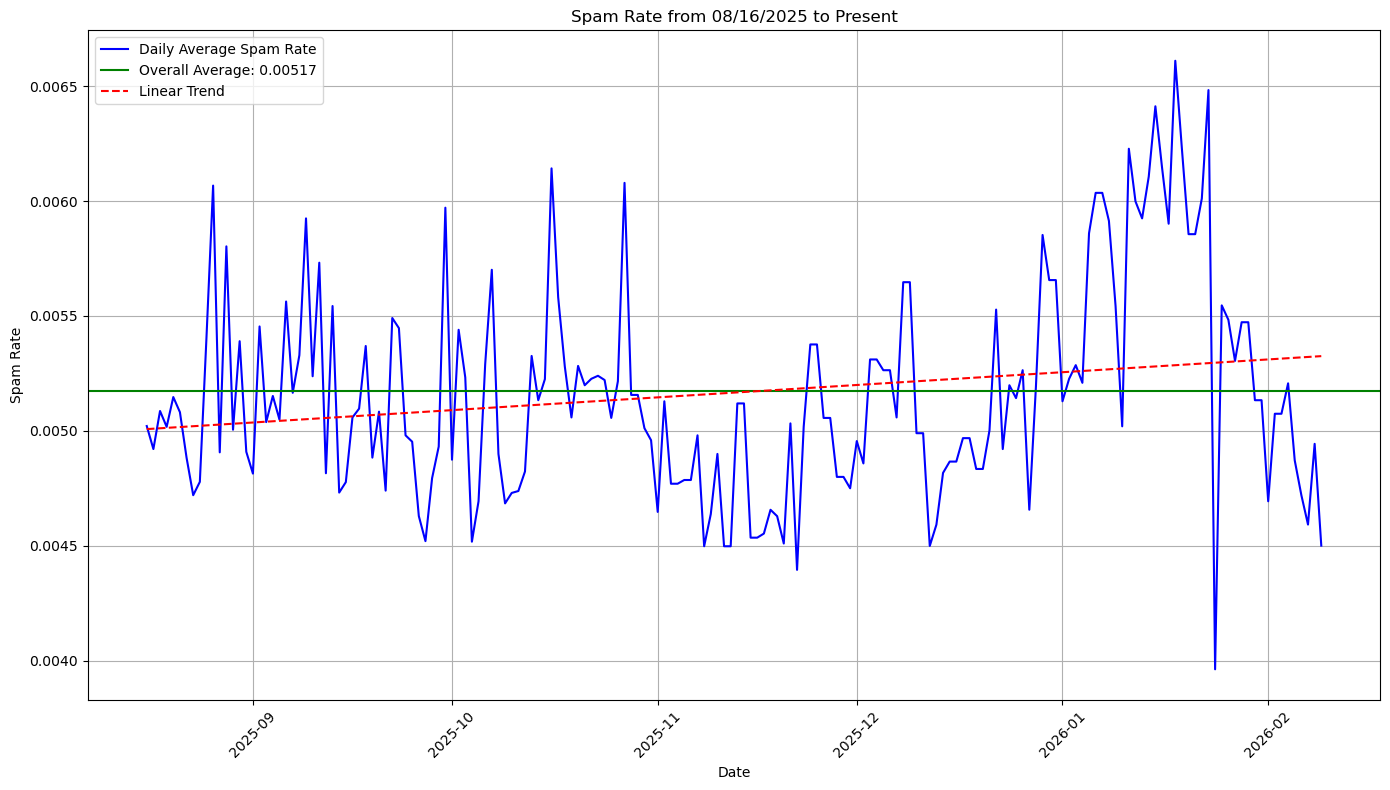

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('cleaned_data.csv')

# Ensure the 'Date' column is in the correct datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Define the date range
start_date = pd.to_datetime('2025-08-16')
end_date = df['Date'].max()

# Filter the DataFrame for the date range
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Calculate the overall average Spam Rate for the entire period
overall_avg = df_filtered['Spam Rate'].mean()
print(f"Overall Average Spam Rate: {overall_avg:.5f}")

# Calculate the daily average Spam Rate
daily_avg_spam_rate = df_filtered.groupby('Date')['Spam Rate'].mean().reset_index()

# Reindex to ensure the data frame covers the entire date range
dates_range = pd.date_range(start=start_date, end=end_date)
daily_avg_spam_rate = daily_avg_spam_rate.set_index('Date').reindex(dates_range).fillna(method='ffill').reset_index()

# Convert dates to numerical format for regression
dates_numeric = np.arange(len(dates_range))

# Compute linear fit
# Handle NaN values in the Spam Rate column
valid_indices = ~np.isnan(daily_avg_spam_rate['Spam Rate'])
if sum(valid_indices) > 1:  # Need at least 2 points for linear regression
    dates_numeric_valid = dates_numeric[valid_indices]
    spam_rates_valid = daily_avg_spam_rate['Spam Rate'][valid_indices]
    slope, intercept = np.polyfit(dates_numeric_valid, spam_rates_valid, 1)
    fit_line = slope * dates_numeric + intercept
else:
    # If not enough valid data points, don't show the trend line
    fit_line = np.array([np.nan] * len(dates_numeric))

# Plotting the results
plt.figure(figsize=(14, 8))  # Make the figure wider
plt.plot(dates_range, daily_avg_spam_rate['Spam Rate'], label='Daily Average Spam Rate', color='blue')

# Add a horizontal line for the overall average
plt.axhline(y=overall_avg, color='green', linestyle='-', label=f'Overall Average: {overall_avg:.5f}')
# Only plot the trend line if we have valid data
if not np.all(np.isnan(fit_line)):
    plt.plot(dates_range, fit_line, linestyle='--', color='red', label='Linear Trend')

plt.xlabel('Date')
plt.ylabel('Spam Rate')
plt.title('Spam Rate from 08/16/2025 to Present')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1836128225.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Centered_Spam_Rate'] = subset_df['Spam Rate'] - subset_df['Spam Rate'].mean()


                            OLS Regression Results                            
Dep. Variable:     Centered_Spam_Rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     36.90
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          3.41e-193
Time:                        10:33:25   Log-Likelihood:                 3708.0
No. Observations:                 652   AIC:                            -7192.
Df Residuals:                     540   BIC:                            -6690.
Df Model:                         111                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
abccareerline.com 

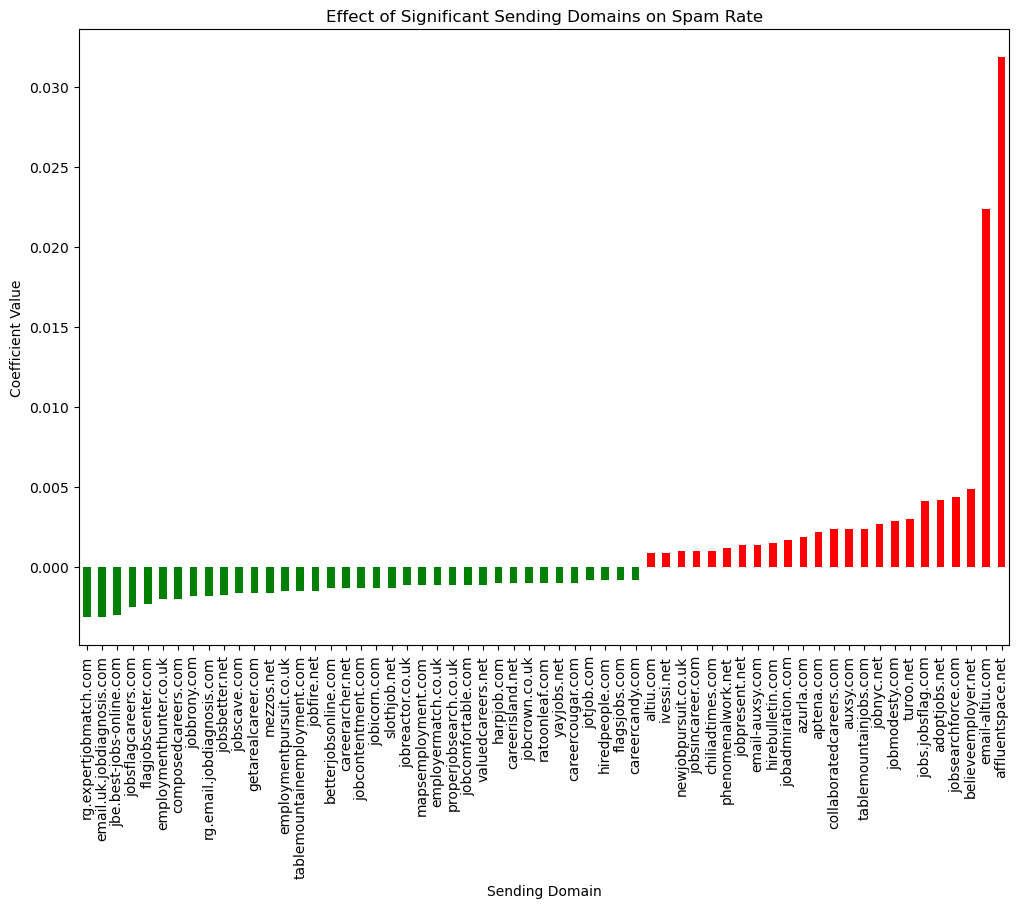

Positive coefficients:
adoptjobs.net, affluentspace.net, altiu.com, aptena.com, auxsy.com, azurla.com, believeemployer.net, chiliadtimes.com, collaboratedcareers.com, email-altiu.com, email-auxsy.com, hirebulletin.com, ivessi.net, jobadmiration.com, jobmodesty.com, jobnyc.net, jobpresent.net, jobs.jobsflag.com, jobsearchforce.com, jobsincareer.com, newjobpursuit.co.uk, phenomenalwork.net, tablemountainjobs.com, turoo.net
 
"adoptjobs.net", "affluentspace.net", "altiu.com", "aptena.com", "auxsy.com", "azurla.com", "believeemployer.net", "chiliadtimes.com", "collaboratedcareers.com", "email-altiu.com", "email-auxsy.com", "hirebulletin.com", "ivessi.net", "jobadmiration.com", "jobmodesty.com", "jobnyc.net", "jobpresent.net", "jobs.jobsflag.com", "jobsearchforce.com", "jobsincareer.com", "newjobpursuit.co.uk", "phenomenalwork.net", "tablemountainjobs.com", "turoo.net"
 
There are 24 domains with positive coefficients.
Negative coefficients:
betterjobsonline.com, careerarcher.net, careercan

C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1836128225.py:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  avg_higher_spam_rate = avg_higher_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()
C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1836128225.py:108: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  avg_lower_spam_rate = avg_lower_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()
C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1836128225.py:109: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  overall_avg_spam_rate = overall_avg_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()


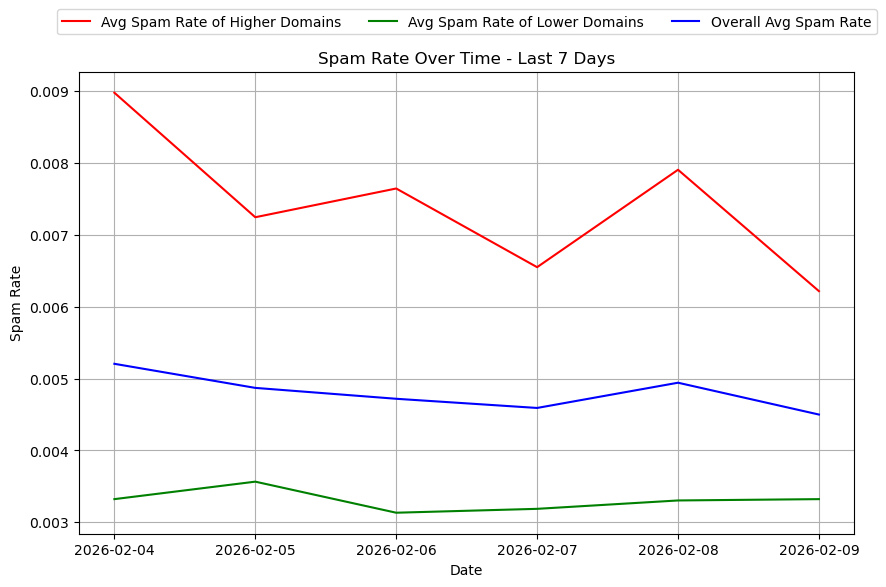

In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# First snippet: Regression and Plot for Spam Rate across Domains
# Load the dataset
df = pd.read_csv('cleaned_data.csv')

# Ensure the 'Date' column is in the correct datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Subset the data to include only the most recent 7 days
most_recent_date = df['Date'].max()
subset_df = df[df['Date'] > most_recent_date - pd.Timedelta(days=7)]

# Center the Spam Rate around its mean
subset_df['Centered_Spam_Rate'] = subset_df['Spam Rate'] - subset_df['Spam Rate'].mean()

# Creating variables for each Sending Domain
X = pd.get_dummies(subset_df['Sending Domain'], drop_first=False)
y = subset_df['Centered_Spam_Rate']

# Fit the OLS model without a constant (since we've centered the data)
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())

# Extracting significant variables' coefficients
significant_coeffs = model.params[model.pvalues < 0.05]

# Sort significant_coeffs by their values in ascending order
significant_coeffs_sorted = significant_coeffs.sort_values()

# Plotting significant Sending Domains and their coefficients after sorting
plt.figure(figsize=(12, 8))  # Making the graph larger
colors = ['red' if x > 0 else 'green' for x in significant_coeffs_sorted]
significant_coeffs_sorted.plot(kind='bar', color=colors)
plt.title('Effect of Significant Sending Domains on Spam Rate')
plt.xlabel('Sending Domain')
plt.ylabel('Coefficient Value')
plt.show()

# Extract domains with positive coefficients
positive_significant_domains = significant_coeffs[significant_coeffs > 0].index.tolist()
# Extract domains with negative coefficients
negative_significant_domains = significant_coeffs[significant_coeffs < 0].index.tolist()

# Function to remove .net/.com/etc.
def strip_domain(domain):
    return domain.split('.')[0]

# Print positive domains
print("Positive coefficients:")
print(", ".join(positive_significant_domains))
print(" ")
print(", ".join(f'"{domain}"' for domain in positive_significant_domains))
print(" ")
print(f"There are {len(positive_significant_domains)} domains with positive coefficients.")

# Print negative domains
print("Negative coefficients:")
print(", ".join(negative_significant_domains))
print(" ")
print(", ".join(f'"{domain}"' for domain in negative_significant_domains))
print(" ")
print(f"There are {len(negative_significant_domains)} domains with negative coefficients.")

# Print raw domains without .net/.com/etc. separated by |
positive_raw_domains = [strip_domain(domain) for domain in positive_significant_domains]
negative_raw_domains = [strip_domain(domain) for domain in negative_significant_domains]

print("Raw positive domains:")
print("|".join(positive_raw_domains))
print(f"There are {len(positive_raw_domains)} raw domains with positive coefficients.")

print("Raw negative domains:")
print("|".join(negative_raw_domains))
print(f"There are {len(negative_raw_domains)} raw domains with negative coefficients.")

# Second snippet: Model the higher, average, and lower domains
# Load the dataset
df = pd.read_csv('cleaned_data.csv')

# Ensure the 'Date' column is in the correct datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Filter the DataFrame to include only the most recent 7 days
most_recent_date = df['Date'].max()
last_7_days = most_recent_date - pd.Timedelta(days=6)  # Includes the most recent day and the previous 6 days
df = df[df['Date'] >= last_7_days]

# Filter the DataFrame for significant higher and lower domains
significant_higher_df = df[df['Sending Domain'].isin(positive_significant_domains)]
significant_lower_df = df[df['Sending Domain'].isin(negative_significant_domains)]

# Calculate the average Spam Rate for the significant domains over time
avg_higher_spam_rate = significant_higher_df.groupby('Date')['Spam Rate'].mean().reset_index()
avg_lower_spam_rate = significant_lower_df.groupby('Date')['Spam Rate'].mean().reset_index()

# Calculate the overall average Spam Rate over time across all domains
overall_avg_spam_rate = df.groupby('Date')['Spam Rate'].mean().reset_index()

# Reindex to ensure all data frames cover the last 7 days
dates = pd.date_range(start=last_7_days, end=most_recent_date)
avg_higher_spam_rate = avg_higher_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()
avg_lower_spam_rate = avg_lower_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()
overall_avg_spam_rate = overall_avg_spam_rate.set_index('Date').reindex(dates).fillna(method='ffill').reset_index()

# Convert dates to numerical format for regression
dates_numeric = np.arange(len(dates))

# Compute linear fits
slope_higher, intercept_higher = np.polyfit(dates_numeric, avg_higher_spam_rate['Spam Rate'], 1)
fit_higher = slope_higher * dates_numeric + intercept_higher

slope_lower, intercept_lower = np.polyfit(dates_numeric, avg_lower_spam_rate['Spam Rate'], 1)
fit_lower = slope_lower * dates_numeric + intercept_lower

slope_overall, intercept_overall = np.polyfit(dates_numeric, overall_avg_spam_rate['Spam Rate'], 1)
fit_overall = slope_overall * dates_numeric + intercept_overall

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(dates, avg_higher_spam_rate['Spam Rate'], label='Avg Spam Rate of Higher Domains', color='red')
plt.plot(dates, fit_higher, linestyle='--', color='red')
plt.plot(dates, avg_lower_spam_rate['Spam Rate'], label='Avg Spam Rate of Lower Domains', color='green')
plt.plot(dates, fit_lower, linestyle='--', color='green')
plt.plot(dates, overall_avg_spam_rate['Spam Rate'], label='Overall Avg Spam Rate', color='blue')
plt.plot(dates, fit_overall, linestyle='--', color='blue')
plt.xlabel('Date')
plt.ylabel('Spam Rate')
plt.title('Spam Rate Over Time - Last 7 Days')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.grid(True)
plt.show()


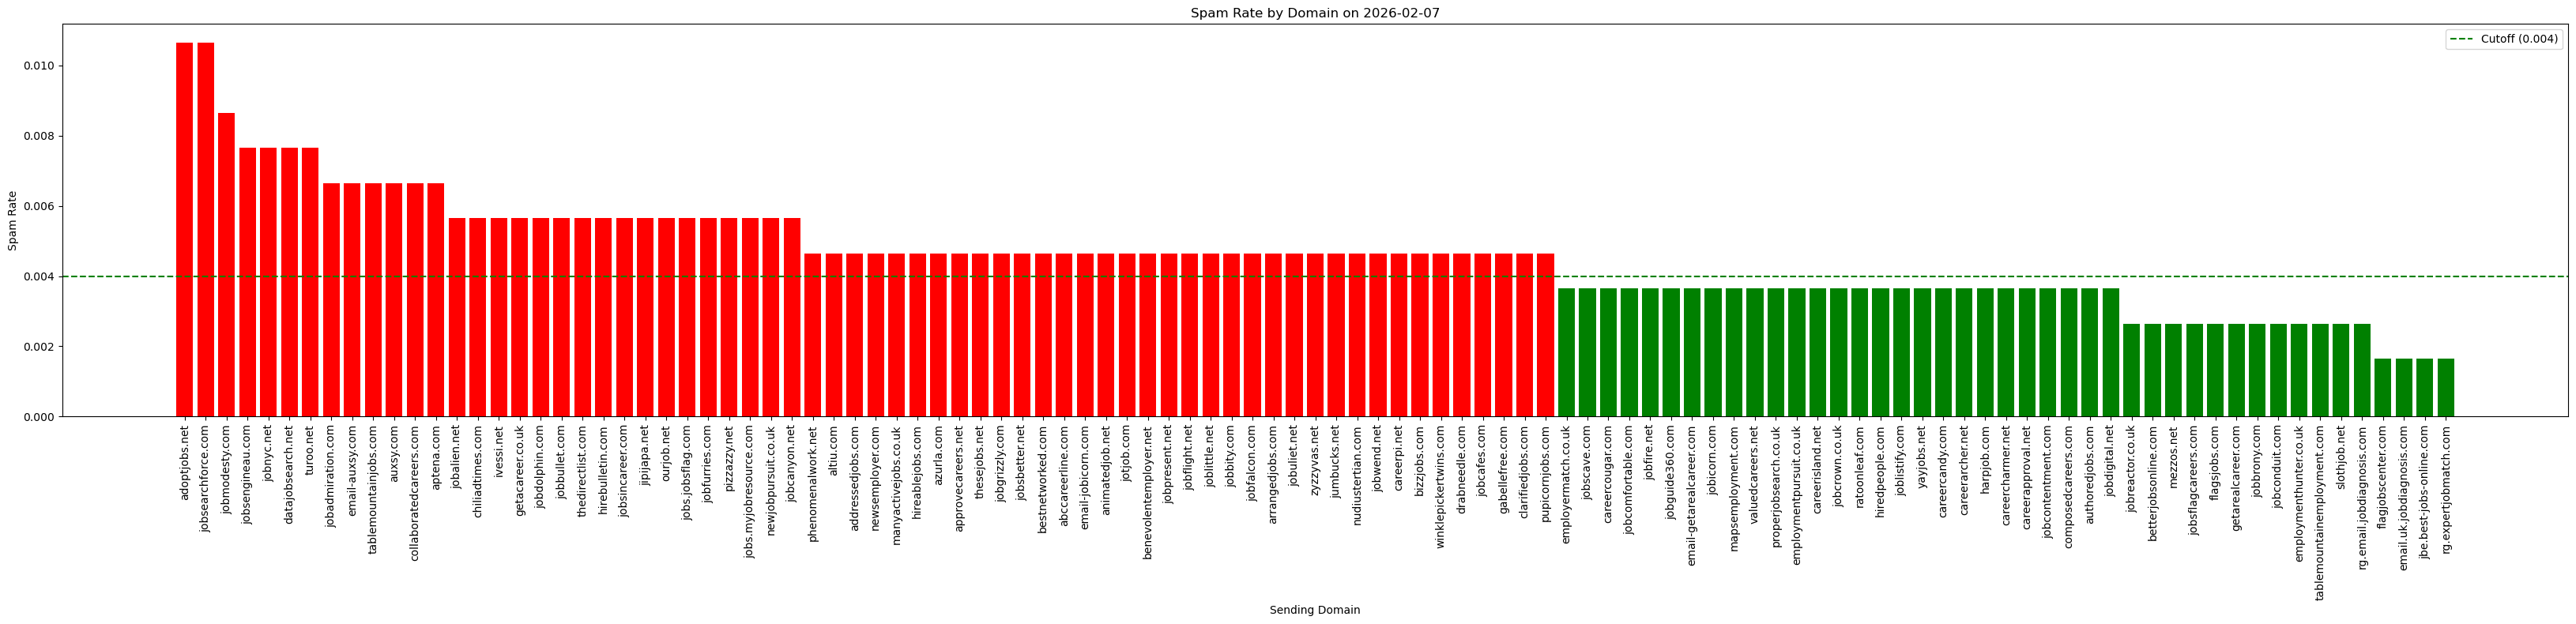

In [4]:
# Update date to one day prior 

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('cleaned_data.csv')

# Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Define the target date
target_date = pd.to_datetime('2026-02-07')

# Filter the data for the target date
latest_data = data[data['Date'] == target_date]

# Sort data by Spam Rate for better visibility
latest_data_sorted = latest_data.sort_values(by='Spam Rate', ascending=False)

# Filter for significant spam rates, if needed (e.g., rates > 0.001)
filtered_data = latest_data_sorted[latest_data_sorted['Spam Rate'] > 0.001]

# Number of domains
num_domains = len(filtered_data)

# Setup the plot with dynamic width based on the number of domains
fig, ax = plt.subplots(figsize=(max(12, num_domains * 0.3), 8))  # 0.3 inch per domain

# Plotting
colors = ['red' if x > 0.004 else 'green' for x in filtered_data['Spam Rate']]
ax.bar(filtered_data['Sending Domain'], filtered_data['Spam Rate'], color=colors, width=0.8)  # Maintain bar width

# Add a horizontal line for cutoff
ax.axhline(y=0.004, color='green', linestyle='--', label='Cutoff (0.004)')

# Labeling and title
plt.xlabel('Sending Domain')
plt.ylabel('Spam Rate')
plt.title('Spam Rate by Domain on 2026-02-07')
plt.xticks(rotation=90)  # Rotate domain labels for better visibility
plt.legend()
plt.tight_layout()  # Adjust layout to fit everything neatly

# Display the plot
plt.show()


In [5]:
import pandas as pd

# Load the dataset
data = pd.read_csv('cleaned_data.csv')

# Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set the target date
target_date = pd.to_datetime('2026-02-07')

# Filter the data for the target date
latest_data = data[data['Date'] == target_date]

# Identify domains with a Spam Rate greater than 0.004
high_spam_domains = latest_data[latest_data['Spam Rate'] > 0.004]

# Collect the list of domains
domain_list = high_spam_domains['Sending Domain'].tolist()

# Count the number of domains
domain_count = len(domain_list)

# Print the domains separated by a comma and their count
print("Domains with a Spam Rate greater than 0.004:", ", ".join(domain_list))
print("Total number of domains:", domain_count)


Domains with a Spam Rate greater than 0.004: aptena.com, careerpi.net, jobfalcon.com, jobfurries.com, newjobpursuit.co.uk, joblittle.net, jobcanyon.net, drabneedle.com, jobuliet.net, pizzazzy.net, gabellefree.com, pupicornjobs.com, ourjob.net, auxsy.com, arrangedjobs.com, jipijapa.net, zyzzyvas.net, jumbucks.net, nudiustertian.com, tablemountainjobs.com, jobwend.net, bizzjobs.com, jobbity.com, jobcafes.com, jobsincareer.com, chiliadtimes.com, clarifiedjobs.com, jobbullet.com, adoptjobs.net, winklepickertwins.com, jobgrizzly.com, jobpresent.net, addressedjobs.com, thedirectlist.com, jobdolphin.com, jobflight.net, hireablejobs.com, getacareer.co.uk, altiu.com, thesejobs.net, approvecareers.net, jobadmiration.com, turoo.net, bestnetworked.com, ivessi.net, abccareerline.com, jobmodesty.com, jobnyc.net, jotjob.com, hirebulletin.com, phenomenalwork.net, jobalien.net, benevolentemployer.net, animatedjob.net, email-auxsy.com, email-jobicorn.com, datajobsearch.net, jobsbetter.net, jobs.myjobres

In [6]:
###Analyze Engagement
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('cleaned_data.csv')

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Determine the most recent date in the dataset
max_date = df['Date'].max()

# Filter the data to include only the last 7 days
filtered_df = df[(df['Date'] > max_date - pd.Timedelta(days=7)) & (df['Date'] <= max_date)]

# Selecting the independent variables and the dependent variable
X = filtered_df[['Sent', 'Open Rate', 'Click Rate', 'Unsubscribe Rate']]
y = filtered_df['Spam Rate']

# Standardizing the variables (only X here)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame for the scaled variables, adding '-z-' to each original column name
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'{col}-z-' for col in X.columns], index=X.index)

# Adding a constant to the model (intercept)
X_scaled_with_constant = sm.add_constant(X_scaled_df)

# Fit the model
model = sm.OLS(y, X_scaled_with_constant).fit()

# Print out the regression table
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Spam Rate   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     34.33
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           5.23e-26
Time:                        10:36:34   Log-Likelihood:                 3069.9
No. Observations:                 652   AIC:                            -6130.
Df Residuals:                     647   BIC:                            -6107.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0048   8

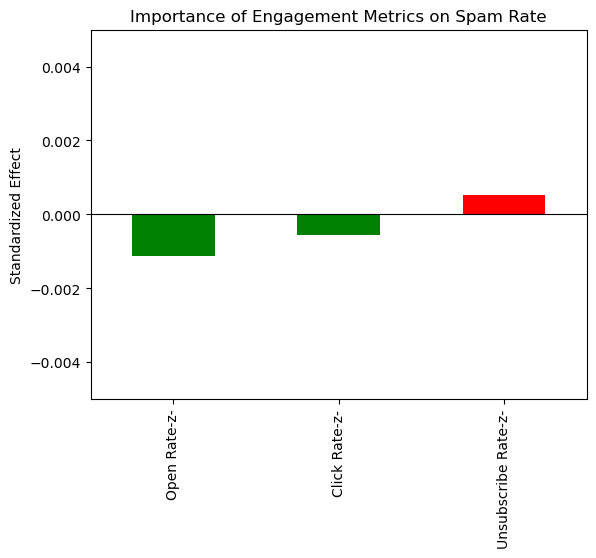

In [7]:
###PLot Engagement
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('cleaned_data.csv')

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Determine the most recent date in the dataset
max_date = df['Date'].max()

# Filter the data to include only the last 7 days (or a moving window)
filtered_df = df[(df['Date'] > max_date - pd.Timedelta(days=7)) & (df['Date'] <= max_date)]

# Selecting the independent variables and the dependent variable
X = filtered_df[['Sent', 'Open Rate', 'Click Rate', 'Unsubscribe Rate']]
y = filtered_df['Spam Rate']

# Standardizing the independent variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame for the scaled variables, adding '-z-' to each original column name
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'{col}-z-' for col in X.columns], index=X.index)

# Adding a constant to the model (intercept)
X_scaled_with_constant = sm.add_constant(X_scaled_df)

# Fit the model using the standardized variables
model = sm.OLS(y, X_scaled_with_constant).fit()

# Extracting the parameters and their p-values
params = model.params
p_values = model.pvalues

# Filter parameters based on the significance of their p-values
significant_params = params[p_values < 0.05]

# Removing the constant if it's not significant
significant_params = significant_params.drop('const', errors='ignore')

# Ensure there are significant parameters before plotting
if not significant_params.empty:
    # Define colors based on the sign of the coefficients (switched colors)
    colors = ['red' if x > 0 else 'green' for x in significant_params]

    # Plotting the bar chart
    significant_params.plot(kind='bar', color=colors)
    plt.ylabel('Standardized Effect')
    plt.title('Importance of Engagement Metrics on Spam Rate')
    plt.axhline(0, color='black', linewidth=0.8)  # Add a line at zero
    plt.ylim(-0.005, 0.005)  # Lock the y-axis

    # Save the figure before showing it
    plt.savefig('fig2.png', dpi=300)  # Saves the figure with high resolution

    # Display the plot
    plt.show()
else:
    print("No significant parameters to display.")


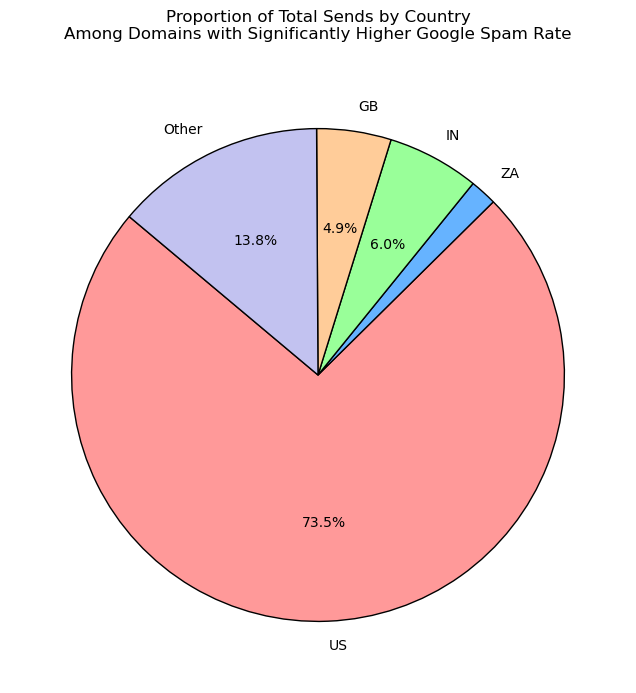

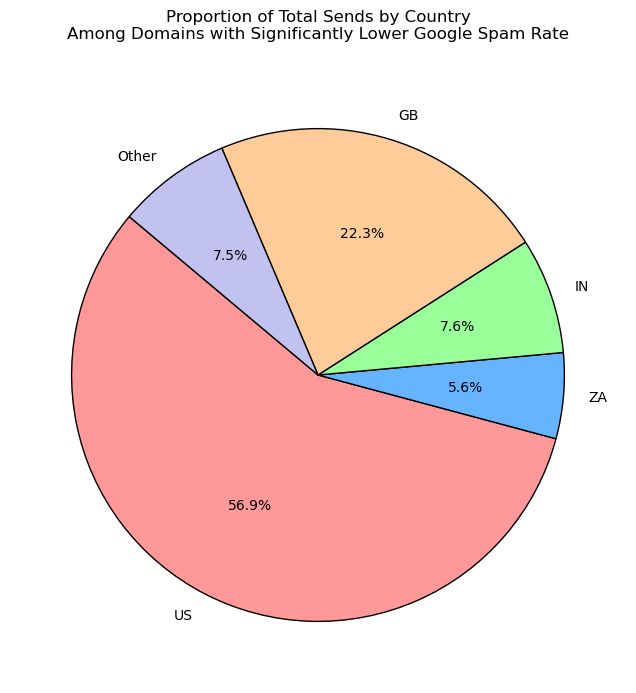

In [9]:
###Download past 7 day esp data for high and low domains seperated by country -> Only GMAIL

import pandas as pd
import matplotlib.pyplot as plt

def custom_autopct(pct):
    return ('{p:.1f}%'.format(p=pct)) if pct > 2 else ''

def generate_pie_chart(data, title):
    total_sends = data['Sent'].sum()
    sends_by_all_countries = data.groupby('List Country')['Sent'].sum()

    sends_adjusted = sends_by_all_countries.loc[['US', 'ZA', 'IN', 'GB']]
    sends_adjusted['Other'] = sends_by_all_countries.drop(['US', 'ZA', 'IN', 'GB']).sum()
    proportion_adjusted = sends_adjusted / total_sends

    plt.figure(figsize=(10, 8))
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
    patches, texts, autotexts = plt.pie(proportion_adjusted, labels=proportion_adjusted.index, autopct=custom_autopct, startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
    plt.title(title, pad=20)
    plt.show()

# Load the datasets
file_path_higher = 'Higher Domain Sends.csv'  # Change this to your actual file path
file_path_lower = 'Lower Domain Sends.csv'    # Change this to your actual file path

data_higher_spam_rate = pd.read_csv(file_path_higher)
data_lower_spam_rate = pd.read_csv(file_path_lower)

# Generate the pie charts
generate_pie_chart(data_higher_spam_rate, 'Proportion of Total Sends by Country\nAmong Domains with Significantly Higher Google Spam Rate')
generate_pie_chart(data_lower_spam_rate, 'Proportion of Total Sends by Country\nAmong Domains with Significantly Lower Google Spam Rate')


In [12]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this to the path of your cleaned data
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle the data filtering and saving
def filter_data(b):
    domains = [x.strip() for x in domain_input.value.split(',')]
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Specify the file name for the filtered data
        filtered_file_path = 'acute_domains.csv'  # You can customize this file name
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"Filtered data saved to {filtered_file_path}. Selected {len(filtered_data)} rows with domains {domains} from {start_date} to {end_date}.")
    else:
        print("Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)

### Rename filtered_data based on test group name as needed 


Text(value='', continuous_update=False, description='Domains:', placeholder='Enter domains separated by commas…

DatePicker(value=Timestamp('2025-08-26 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2026-01-26 00:00:00'), description='End Date', step=1)

Button(description='Filter and Save Data', style=ButtonStyle())

In [8]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this to the path of your cleaned data
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle the data filtering and saving
def filter_data(b):
    domains = [x.strip() for x in domain_input.value.split(',')]
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Specify the file name for the filtered data
        filtered_file_path = 'chronic_domains.csv'  # You can customize this file name
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"Filtered data saved to {filtered_file_path}. Selected {len(filtered_data)} rows with domains {domains} from {start_date} to {end_date}.")
    else:
        print("Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)

### Rename filtered_data based on test group name as needed 


Text(value='', continuous_update=False, description='Domains:', placeholder='Enter domains separated by commas…

DatePicker(value=Timestamp('2025-08-09 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2026-02-09 00:00:00'), description='End Date', step=1)

Button(description='Filter and Save Data', style=ButtonStyle())

In [14]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this to the path of your cleaned data
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle the data filtering and saving
def filter_data(b):
    domains = [x.strip() for x in domain_input.value.split(',')]
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Specify the file name for the filtered data
        filtered_file_path = 'prophylactic_domains.csv'  # You can customize this file name
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"Filtered data saved to {filtered_file_path}. Selected {len(filtered_data)} rows with domains {domains} from {start_date} to {end_date}.")
    else:
        print("Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)

### Rename filtered_data based on test group name as needed 


Text(value='', continuous_update=False, description='Domains:', placeholder='Enter domains separated by commas…

DatePicker(value=Timestamp('2025-08-26 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2026-01-26 00:00:00'), description='End Date', step=1)

Button(description='Filter and Save Data', style=ButtonStyle())

In [15]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this to the path of your cleaned data
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle the data filtering and saving
def filter_data(b):
    domains = [x.strip() for x in domain_input.value.split(',')]
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Specify the file name for the filtered data
        filtered_file_path = 'liveintent_domains.csv'  # You can customize this file name
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"Filtered data saved to {filtered_file_path}. Selected {len(filtered_data)} rows with domains {domains} from {start_date} to {end_date}.")
    else:
        print("Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)

### Rename filtered_data based on test group name as needed 


Text(value='', continuous_update=False, description='Domains:', placeholder='Enter domains separated by commas…

DatePicker(value=Timestamp('2025-08-26 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2026-01-26 00:00:00'), description='End Date', step=1)

Button(description='Filter and Save Data', style=ButtonStyle())

In [9]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'chronic_domains.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2026-02-03')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


  Domain Group    Sending Domain       Date DateGroup    Sent  Delivered  \
0        Gmail  careerisland.net 2026-01-28    28-Jan  384806   384696.0   
1        Gmail  careerisland.net 2026-01-30    30-Jan  381272   381178.0   
2        Gmail  careerisland.net 2026-01-26    26-Jan  381166   381064.0   
3        Gmail  careerisland.net 2026-01-27    27-Jan  380857   380755.0   
4        Gmail  careerisland.net 2026-02-01     1-Feb  380251   380155.0   

    Opens  Clicks  Unsubscribes  Disabled  ...  Raw Unsubscribes  \
0  157850    3052          3398       105  ...              3557   
1  157643    3160          3065        90  ...              3237   
2  163006    3213          3673        98  ...              4012   
3  154461    2884          3572       100  ...              3751   
4  158136    2890          2920        90  ...              3099   

   Raw Complaints  Raw Disabled  Complaint Rate  complaint_rate_from_gpmt  \
0            2390           105          0.7647          

In [17]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'acute_domains.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2025-11-08')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


  Domain Group    Sending Domain       Date DateGroup    Sent  Delivered  \
0        Gmail  careercougar.com 2025-11-28    28-Nov  545780   545642.0   
1        Gmail  careercougar.com 2026-01-23    23-Jan  545018   544868.0   
2        Gmail  careercougar.com 2025-11-21    21-Nov  544130   543988.0   
3        Gmail  careercougar.com 2025-11-23    23-Nov  543902   543770.0   
4        Gmail  careercougar.com 2025-10-29    29-Oct  543767   543643.0   

    Opens  Clicks  Unsubscribes  Disabled  ...  Raw Unsubscribes  \
0  246664    3627          4189       135  ...              4405   
1  269739    4857          4862       147  ...              5090   
2  262446    4026          4418       138  ...              4612   
3  255859    3993          4439       130  ...              4664   
4  272193    4813          4984       123  ...              5252   

   Raw Complaints  Raw Disabled  Complaint Rate  complaint_rate_from_gpmt  \
0            2490           135          0.5647          

In [18]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'prophylactic_domains.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2025-11-08')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


  Domain Group        Sending Domain       Date DateGroup     Sent  Delivered  \
0        Gmail           yayjobs.net 2025-08-27    27-Aug  1093521  1093473.0   
1        Gmail           yayjobs.net 2025-09-15    15-Sep  1065072  1065030.0   
2        Gmail           yayjobs.net 2026-01-23    23-Jan  1056139  1056071.0   
3        Gmail  betterjobsonline.com 2025-08-27    27-Aug  1050716  1050683.0   
4        Gmail           yayjobs.net 2025-08-31    31-Aug  1048834  1048798.0   

    Opens  Clicks  Unsubscribes  Disabled  ...  Raw Unsubscribes  \
0  670377    8948         11047        48  ...             11385   
1  353191    3708          6870        41  ...              7167   
2  475488    7273          7125        68  ...              7662   
3  547850    9315         11674        33  ...             12135   
4  560245    6713          8390        36  ...              8758   

   Raw Complaints  Raw Disabled  Complaint Rate  complaint_rate_from_gpmt  \
0            3873          

In [19]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'liveintent_domains.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2025-12-16')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


  Domain Group    Sending Domain       Date DateGroup    Sent  Delivered  \
0        Gmail  careerisland.net 2025-11-26    26-Nov  482573   482421.0   
1        Gmail  careerisland.net 2025-11-22    22-Nov  478826   478693.0   
2        Gmail  careerisland.net 2025-11-20    20-Nov  477550   477416.0   
3        Gmail  careerisland.net 2025-11-28    28-Nov  476675   476531.0   
4        Gmail  careerisland.net 2025-12-05     5-Dec  475374   475223.0   

    Opens  Clicks  Unsubscribes  Disabled  ...  Raw Unsubscribes  \
0  237364    2844          3405       149  ...              3577   
1  234261    2732          3478       132  ...              3886   
2  226734    3102          4054       130  ...              4211   
3  217118    2641          3374       141  ...              3511   
4  164685    3361          3417       149  ...              3627   

   Raw Complaints  Raw Disabled  Complaint Rate  complaint_rate_from_gpmt  \
0            2163           149          0.5647          

C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1816572724.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1816572724.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot

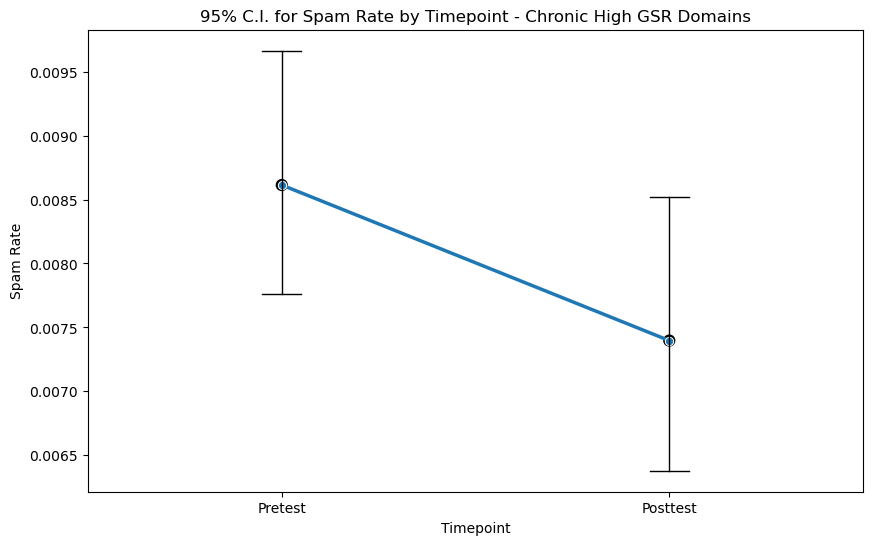

                     Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:       0.012     
Dependent Variable:    Spam Rate          AIC:                  -939.4406 
Date:                  2026-02-13 10:42   BIC:                  -933.9334 
No. Observations:      116                Log-Likelihood:       471.72    
Df Model:              1                  F-statistic:          2.451     
Df Residuals:          114                Prob (F-statistic):   0.120     
R-squared:             0.021              Scale:                1.7495e-05
--------------------------------------------------------------------------
              Coef.     Std.Err.    t    P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------
const      0.0086136667   0.0005 15.9517 0.0000  0.0075439605 0.0096833728
Timepoint -0.0012166667   0.0008 -1.5655 0.1202 -0.0027562368 0.0003229035
-----------------------------------------------

C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1816572724.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1816572724.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0086136667' '-0.0012166667']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_25188\1816572724.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0075439605' '-0.0027562368']' has dtype incompati

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('chronic_domains.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['Pretest', 'Posttest'])

plt.title('95% C.I. for Spam Rate by Timepoint - Chronic High GSR Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3053045334.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3053045334.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x

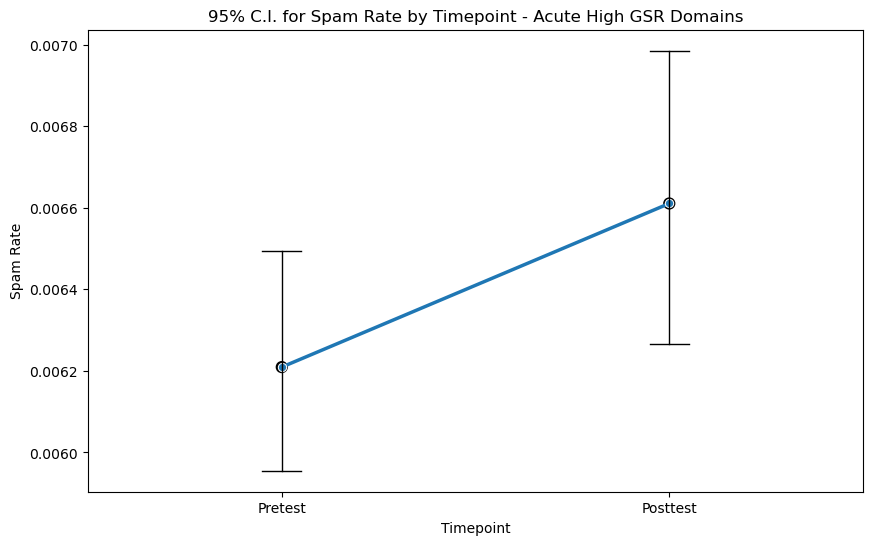

                     Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      0.001      
Dependent Variable:    Spam Rate         AIC:                 -14465.0056
Date:                  2026-01-29 09:33  BIC:                 -14453.9511
No. Observations:      1858              Log-Likelihood:      7234.5     
Df Model:              1                 F-statistic:         3.067      
Df Residuals:          1856              Prob (F-statistic):  0.0801     
R-squared:             0.002             Scale:               2.4320e-05 
-------------------------------------------------------------------------
             Coef.     Std.Err.    t    P>|t|      [0.025       0.975]   
-------------------------------------------------------------------------
const     0.0062092449   0.0002 39.4157 0.0000  0.0059002860 0.0065182038
Timepoint 0.0004013086   0.0002  1.7512 0.0801 -0.0000481361 0.0008507534
-----------------------------------------------------------

C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3053045334.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3053045334.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0062092449' '0.0004013086']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3053045334.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0059002860' '-0.0000481361']' has dtype incompatible 

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('acute_domains.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['Pretest', 'Posttest'])

plt.title('95% C.I. for Spam Rate by Timepoint - Acute High GSR Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\653254969.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\653254969.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x='

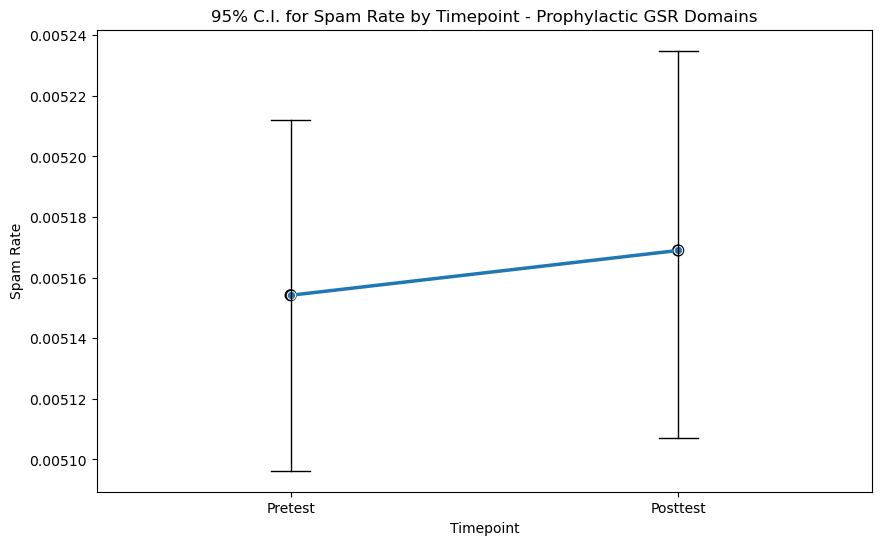

                     Results: Ordinary least squares
Model:                OLS                Adj. R-squared:       -0.000     
Dependent Variable:   Spam Rate          AIC:                  -48159.6121
Date:                 2026-01-29 09:33   BIC:                  -48146.6870
No. Observations:     4734               Log-Likelihood:       24082.     
Df Model:             1                  F-statistic:          0.1154     
Df Residuals:         4732               Prob (F-statistic):   0.734      
R-squared:            0.000              Scale:                2.2346e-06 
--------------------------------------------------------------------------
             Coef.     Std.Err.    t     P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------
const     0.0051541885   0.0000 172.5338 0.0000  0.0050956225 0.0052127545
Timepoint 0.0000147846   0.0000   0.3397 0.7341 -0.0000705464 0.0001001156
-----------------------------------------------

C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\653254969.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\653254969.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0051541885' '0.0000147846']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\653254969.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0050956225' '-0.0000705464']' has dtype incompatible wit

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('prophylactic_domains.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['Pretest', 'Posttest'])

plt.title('95% C.I. for Spam Rate by Timepoint - Prophylactic GSR Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3978897520.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3978897520.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x

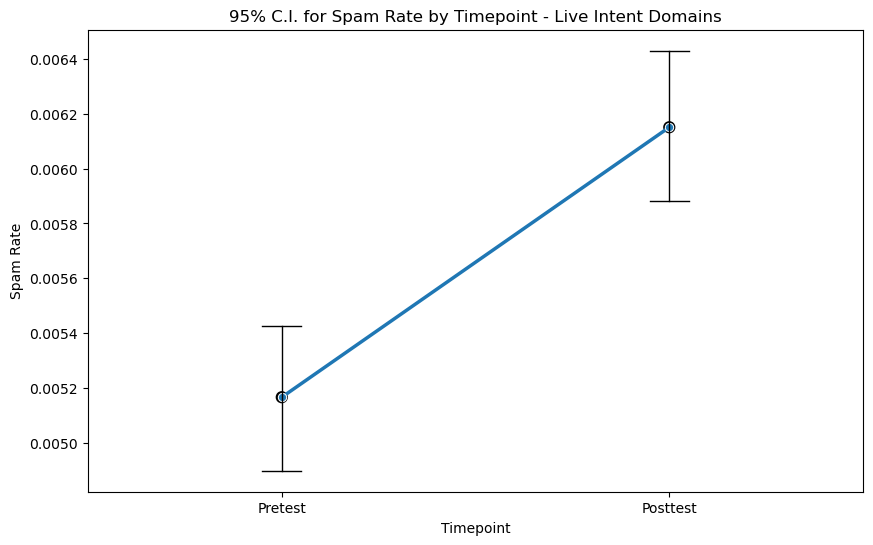

                    Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      0.099     
Dependent Variable:    Spam Rate         AIC:                 -2236.2831
Date:                  2026-01-29 09:33  BIC:                 -2229.5050
No. Observations:      219               Log-Likelihood:      1120.1    
Df Model:              1                 F-statistic:         24.96     
Df Residuals:          217               Prob (F-statistic):  1.20e-06  
R-squared:             0.103             Scale:               2.1323e-06
------------------------------------------------------------------------
             Coef.     Std.Err.    t    P>|t|     [0.025       0.975]   
------------------------------------------------------------------------
const     0.0051655185   0.0001 36.7621 0.0000 0.0048885758 0.0054424613
Timepoint 0.0009859860   0.0002  4.9957 0.0000 0.0005969851 0.0013749869
------------------------------------------------------------------------

C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3978897520.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3978897520.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0051655185' '0.0009859860']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_2252\3978897520.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0048885758' '0.0005969851']' has dtype incompatible w

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('liveintent_domains.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['Pretest', 'Posttest'])

plt.title('95% C.I. for Spam Rate by Timepoint - Live Intent Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this path as needed
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas (leave empty for all)',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle data filtering and saving
def filter_data(b):
    input_value = domain_input.value.strip()
    
    # If input is empty, use all domains
    if input_value == '':
        domains = data['Sending Domain'].unique()
        domain_label = 'all_domains'
    else:
        domains = [x.strip() for x in input_value.split(',')]
        domain_label = '_'.join([d.replace('.', '-') for d in domains])
    
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Save filtered data
        filtered_file_path = f'filtered_{domain_label}.csv'
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"✅ Filtered data saved to {filtered_file_path}.")
        print(f"🔍 Selected {len(filtered_data)} rows from {start_date} to {end_date}.")
    else:
        print("⚠️ Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)


In [ ]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'filtered_all_domains.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2025-06-11')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('filtered_all_domains.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['6/1-10', '6/11-20'])

plt.title('95% C.I. for Spam Rate by Timepoint - All Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


In [17]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Load the cleaned data
file_path = 'cleaned_data.csv'  # Update this to the path of your cleaned data
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'])

# Create widgets
domain_input = widgets.Text(
    value='',
    placeholder='Enter domains separated by commas',
    description='Domains:',
    disabled=False,
    continuous_update=False
)

start_date_picker = widgets.DatePicker(
    description='Start Date',
    disabled=False,
    value=data['Date'].min()
)

end_date_picker = widgets.DatePicker(
    description='End Date',
    disabled=False,
    value=data['Date'].max()
)

# Function to handle the data filtering and saving
def filter_data(b):
    domains = [x.strip() for x in domain_input.value.split(',')]
    start_date = start_date_picker.value
    end_date = end_date_picker.value
    
    if start_date and end_date:
        filtered_data = data[(data['Sending Domain'].isin(domains)) & 
                             (data['Date'] >= pd.to_datetime(start_date)) & 
                             (data['Date'] <= pd.to_datetime(end_date))]
        
        # Specify the file name for the filtered data
        filtered_file_path = 'test.csv'  # You can customize this file name
        filtered_data.to_csv(filtered_file_path, index=False)
        
        print(f"Filtered data saved to {filtered_file_path}. Selected {len(filtered_data)} rows with domains {domains} from {start_date} to {end_date}.")
    else:
        print("Please select both start and end dates.")

# Display widgets
display(domain_input)
display(start_date_picker)
display(end_date_picker)

# Button to apply filters and save the data
apply_button = widgets.Button(description="Filter and Save Data")
apply_button.on_click(filter_data)
display(apply_button)

### Rename filtered_data based on test group name as needed 


Text(value='', continuous_update=False, description='Domains:', placeholder='Enter domains separated by commas…

DatePicker(value=Timestamp('2025-08-01 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2025-12-31 00:00:00'), description='End Date', step=1)

Button(description='Filter and Save Data', style=ButtonStyle())

In [18]:
###Populate Timepoint/Group variable (i.e., pretest vs posttest; control vs test)
import pandas as pd

# Load the dataset
file_path = 'test.csv'
data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Define the cutoff date
cutoff_date = pd.Timestamp('2025-12-16')

# Calculate the 'Timepoint' variable based on the condition
data['Timepoint'] = (data['Date'] >= cutoff_date).astype(int)

# Overwrite the existing file with the updated DataFrame
data.to_csv(file_path, index=False)

# Optionally, display the first few rows to confirm the changes
print(data.head())


  Domain Group  Sending Domain       Date DateGroup      Sent  Delivered  \
0        Gmail  drabneedle.com 2025-12-08     8-Dec  540905.0   540903.0   
1        Gmail  drabneedle.com 2025-12-02     2-Dec  539547.0   539543.0   
2        Gmail  drabneedle.com 2025-12-01     1-Dec  539308.0   539304.0   
3        Gmail  drabneedle.com 2025-12-03     3-Dec  537597.0   537593.0   
4        Gmail  drabneedle.com 2025-12-12    12-Dec  536894.0   536887.0   

      Opens  Clicks  Unsubscribes  Disabled  ...  Raw Unsubscribes  \
0  182427.0  3782.0        4216.0       2.0  ...            4406.0   
1  262860.0  4117.0        5449.0       4.0  ...            5765.0   
2  290286.0  4216.0        5758.0       4.0  ...            6069.0   
3  227631.0  4045.0        4667.0       4.0  ...            4849.0   
4  168879.0  2817.0        2988.0       7.0  ...            3115.0   

   Raw Complaints  Raw Disabled  Complaint Rate  complaint_rate_from_gpmt  \
0          2875.0           2.0          0.66

C:\Users\jthomas\AppData\Local\Temp\ipykernel_26232\3853001665.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jthomas\AppData\Local\Temp\ipykernel_26232\3853001665.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot

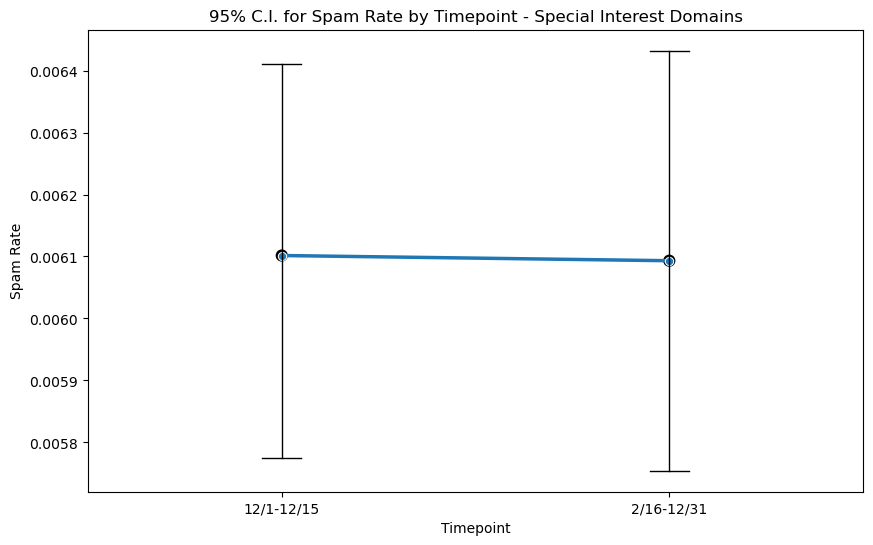

                     Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:       -0.008    
Dependent Variable:    Spam Rate          AIC:                  -1235.4032
Date:                  2026-01-02 11:04   BIC:                  -1229.8282
No. Observations:      120                Log-Likelihood:       619.70    
Df Model:              1                  F-statistic:          0.001078  
Df Residuals:          118                Prob (F-statistic):   0.974     
R-squared:             0.000              Scale:                1.9466e-06
--------------------------------------------------------------------------
              Coef.     Std.Err.    t    P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------
const      0.0061015455   0.0002 32.4327 0.0000  0.0057289985 0.0064740925
Timepoint -0.0000083916   0.0003 -0.0328 0.9739 -0.0005145833 0.0004978001
-----------------------------------------------

C:\Users\jthomas\AppData\Local\Temp\ipykernel_26232\3853001665.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_26232\3853001665.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0061015455' '-0.0000083916']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')
C:\Users\jthomas\AppData\Local\Temp\ipykernel_26232\3853001665.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0057289985' '-0.0005145833']' has dtype incompati

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data
data = pd.read_csv('test.csv')

# Drop rows with missing 'Spam Rate' values
data_cleaned = data.dropna(subset=['Spam Rate'])

plt.figure(figsize=(10, 6))

# Ensure 'Timepoint' is numeric if it's not already
data_cleaned['Timepoint'] = pd.to_numeric(data_cleaned['Timepoint'], errors='coerce')

# Plotting the line without a confidence interval but with increased thickness
sns.lineplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=None, marker='o', linestyle='-', linewidth=2.5)

# Adding the points with thinner confidence intervals, styled similar to a boxplot
sns.pointplot(x='Timepoint', y='Spam Rate', data=data_cleaned, ci=95, join=False, capsize=0.1, errwidth=1, color='black')

# Set custom x-axis tick labels
plt.xticks([0, 1], ['12/1-12/15', '2/16-12/31'])

plt.title('95% C.I. for Spam Rate by Timepoint - Special Interest Domains')
plt.xlabel('Timepoint')
plt.ylabel('Spam Rate')

# Save the figure before showing it
plt.savefig('fig4.png', dpi=300)  # Saves the figure with high resolution

# Display the plot
plt.show()

# Regression Analysis
X = sm.add_constant(data_cleaned['Timepoint'])  # Adds a constant term to the predictor
y = data_cleaned['Spam Rate']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print out the statistics with detailed confidence intervals
summary = model.summary2()

# Format the confidence intervals and beta coefficients to show more decimal places
summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']] = summary.tables[1].loc[:, ['Coef.', '[0.025', '0.975]']].applymap(lambda x: f'{x:.10f}')

# Print the summary
print(summary)


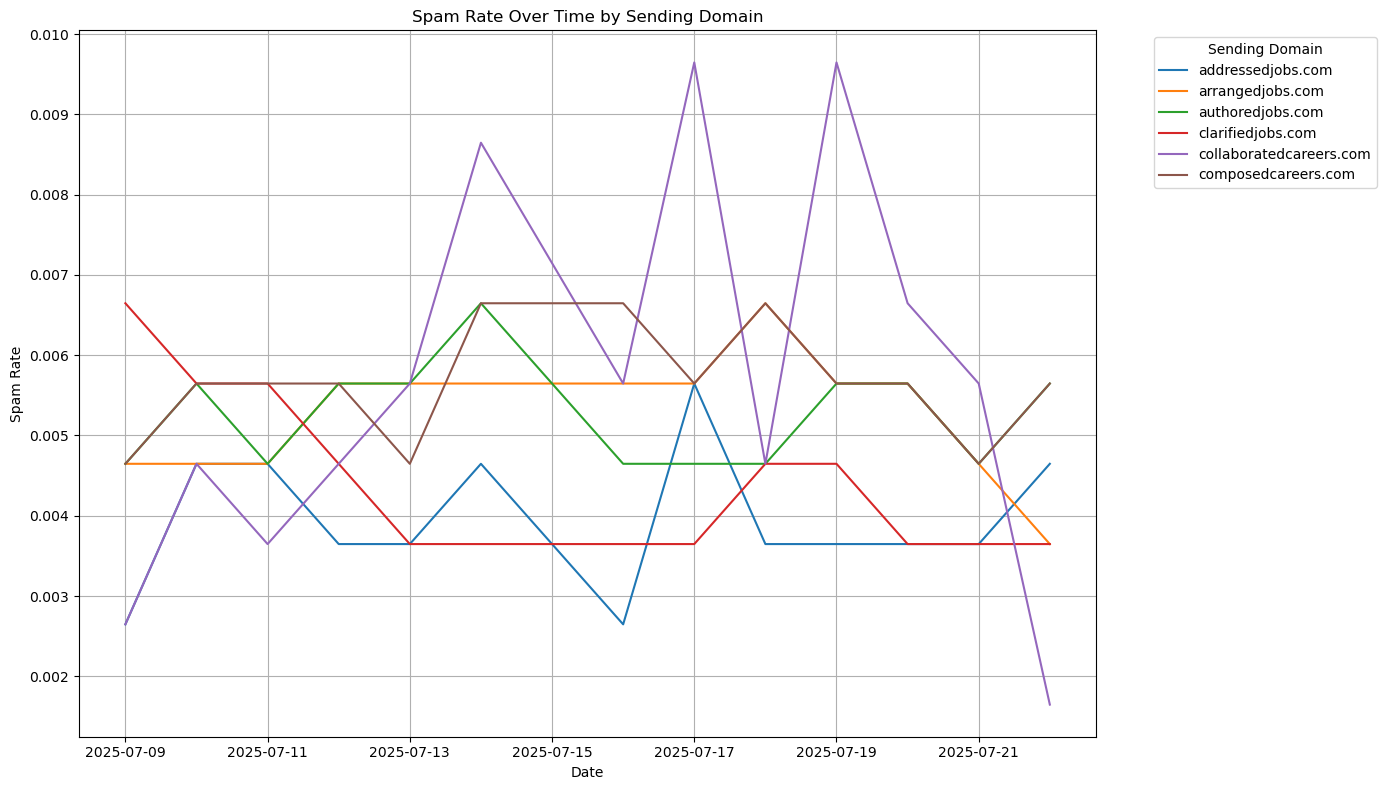

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("aws.csv")

# Ensure correct column types
df['Date'] = pd.to_datetime(df['Date'])

# Pivot the data so each domain is a line over time
pivot_df = df.pivot(index='Date', columns='Sending Domain', values='Spam Rate')

# Plot
plt.figure(figsize=(14, 8))
for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], label=domain)

plt.title("Spam Rate Over Time by Sending Domain")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


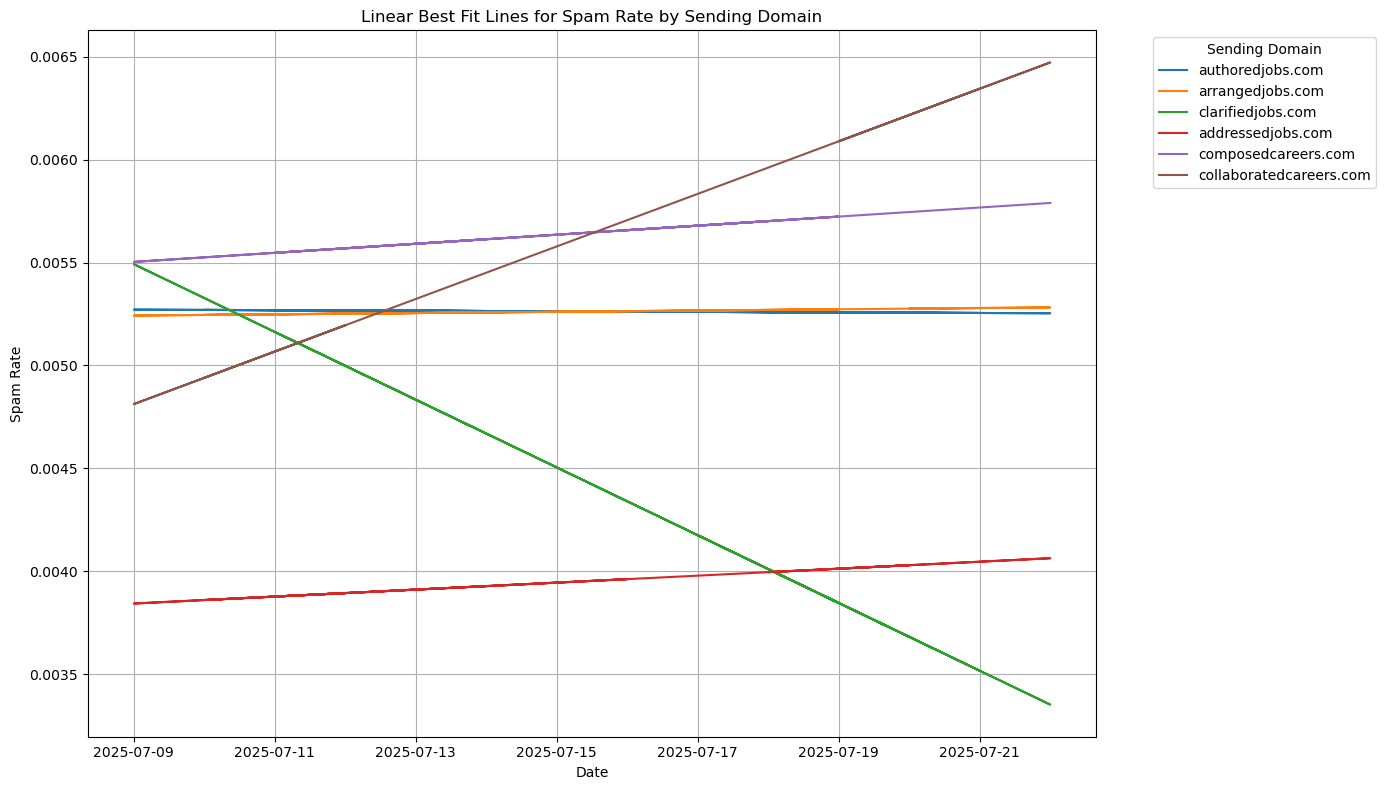

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("aws.csv")

# Convert Date to datetime and then to ordinal for regression
df['Date'] = pd.to_datetime(df['Date'])
df['DateOrdinal'] = df['Date'].map(pd.Timestamp.toordinal)

# Create the plot
plt.figure(figsize=(14, 8))

# Loop through each domain
for domain in df['Sending Domain'].unique():
    domain_df = df[df['Sending Domain'] == domain]
    
    # Drop rows with missing Spam Rate
    domain_df = domain_df.dropna(subset=['Spam Rate'])

    if len(domain_df) < 2:
        continue  # Skip domains with insufficient data

    # Fit a linear regression model
    x = domain_df['DateOrdinal']
    y = domain_df['Spam Rate']
    coeffs = np.polyfit(x, y, deg=1)
    poly = np.poly1d(coeffs)

    # Plot the regression line
    plt.plot(domain_df['Date'], poly(x), label=domain)

# Final plot settings
plt.title("Linear Best Fit Lines for Spam Rate by Sending Domain")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


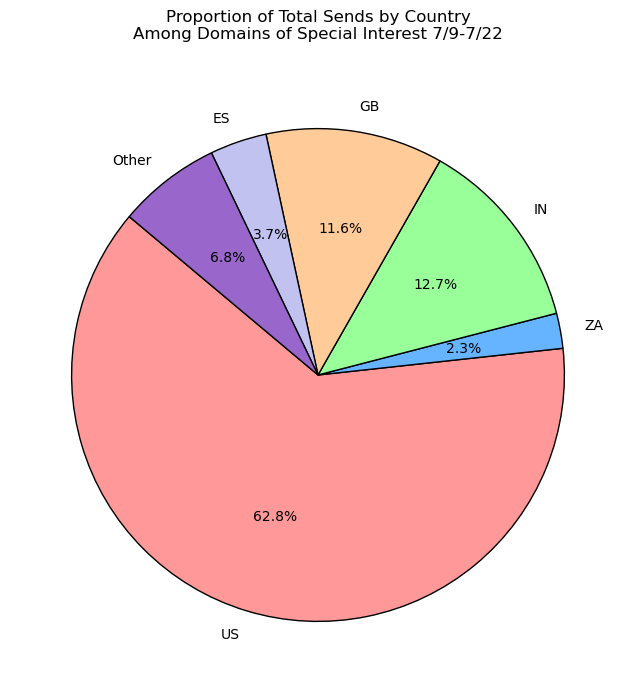

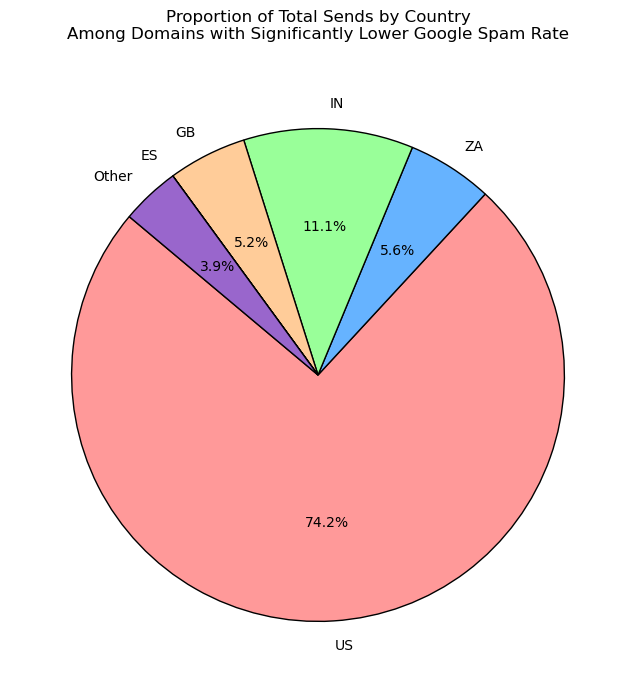

In [8]:
###Download past 7 day esp data for high and low domains seperated by country -> Only GMAIL

import pandas as pd
import matplotlib.pyplot as plt

def custom_autopct(pct):
    return ('{p:.1f}%'.format(p=pct)) if pct > 2 else ''

def generate_pie_chart(data, title):
    total_sends = data['Sent'].sum()
    sends_by_all_countries = data.groupby('User Country')['Sent'].sum()

    sends_adjusted = sends_by_all_countries.loc[['US', 'ZA', 'IN', 'GB', 'ES']]
    sends_adjusted['Other'] = sends_by_all_countries.drop(['US', 'ZA', 'IN', 'GB', 'ES']).sum()
    proportion_adjusted = sends_adjusted / total_sends

    plt.figure(figsize=(10, 8))
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#9966cc']
    patches, texts, autotexts = plt.pie(proportion_adjusted, labels=proportion_adjusted.index, autopct=custom_autopct, startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
    plt.title(title, pad=20)
    plt.show()

# Load the datasets
file_path_higher = 'dat.csv'  # Change this to your actual file path
file_path_lower = 'Lower Domain Sends.csv'    # Change this to your actual file path

data_higher_spam_rate = pd.read_csv(file_path_higher)
data_lower_spam_rate = pd.read_csv(file_path_lower)

# Generate the pie charts
generate_pie_chart(data_higher_spam_rate, 'Proportion of Total Sends by Country\nAmong Domains of Special Interest 7/9-7/22')
generate_pie_chart(data_lower_spam_rate, 'Proportion of Total Sends by Country\nAmong Domains with Significantly Lower Google Spam Rate')


In [12]:
import pandas as pd

# Load the data
df = pd.read_csv('DruidIpReport - 2025-07-24T135554.732.csv')

# Group by Sending Domain and Country, summing the Sends
grouped = df.groupby(['Sending Domain', 'User Country'])['Sent'].sum().reset_index()

# Calculate the total Sends per Sending Domain
total_sends = grouped.groupby('Sending Domain')['Sent'].transform('sum')

# Calculate proportion
grouped['Proportion'] = grouped['Sent'] / total_sends

# Optional: format as percent
grouped['Proportion'] = grouped['Proportion'].round(4)

# Sort the result for readability
grouped = grouped.sort_values(['Sending Domain', 'Proportion'], ascending=[True, False])

# Save the result
grouped.to_csv('sends_by_domain_country_proportion.csv', index=False)


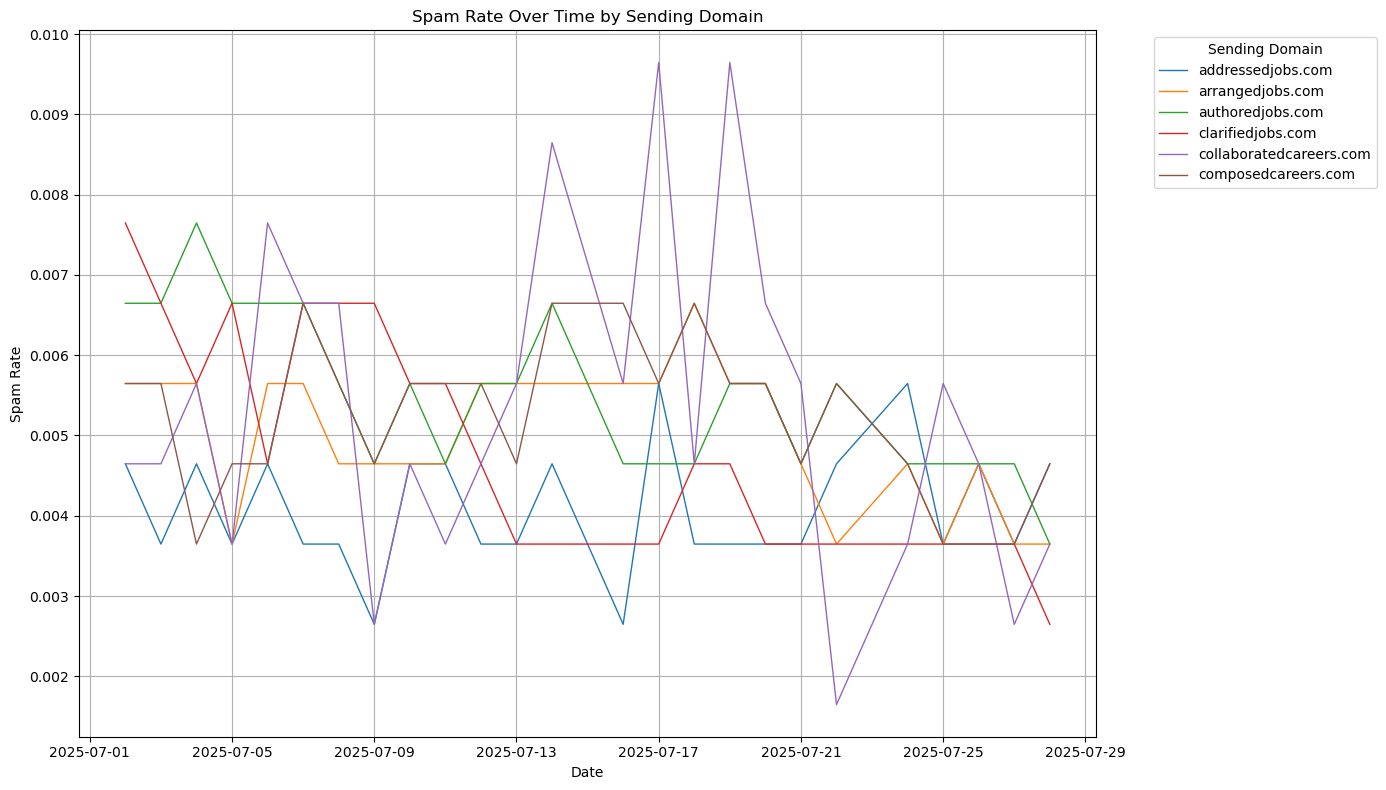

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("aws.csv")

# Ensure dates are in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Pivot the data: rows = Date, columns = Sending Domain, values = Spam Rate
pivot_df = df.pivot_table(index='Date', columns='Sending Domain', values='Spam Rate')

# Plot
plt.figure(figsize=(14, 8))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], label=column, linewidth=1)

plt.title("Spam Rate Over Time by Sending Domain")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(title='Sending Domain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


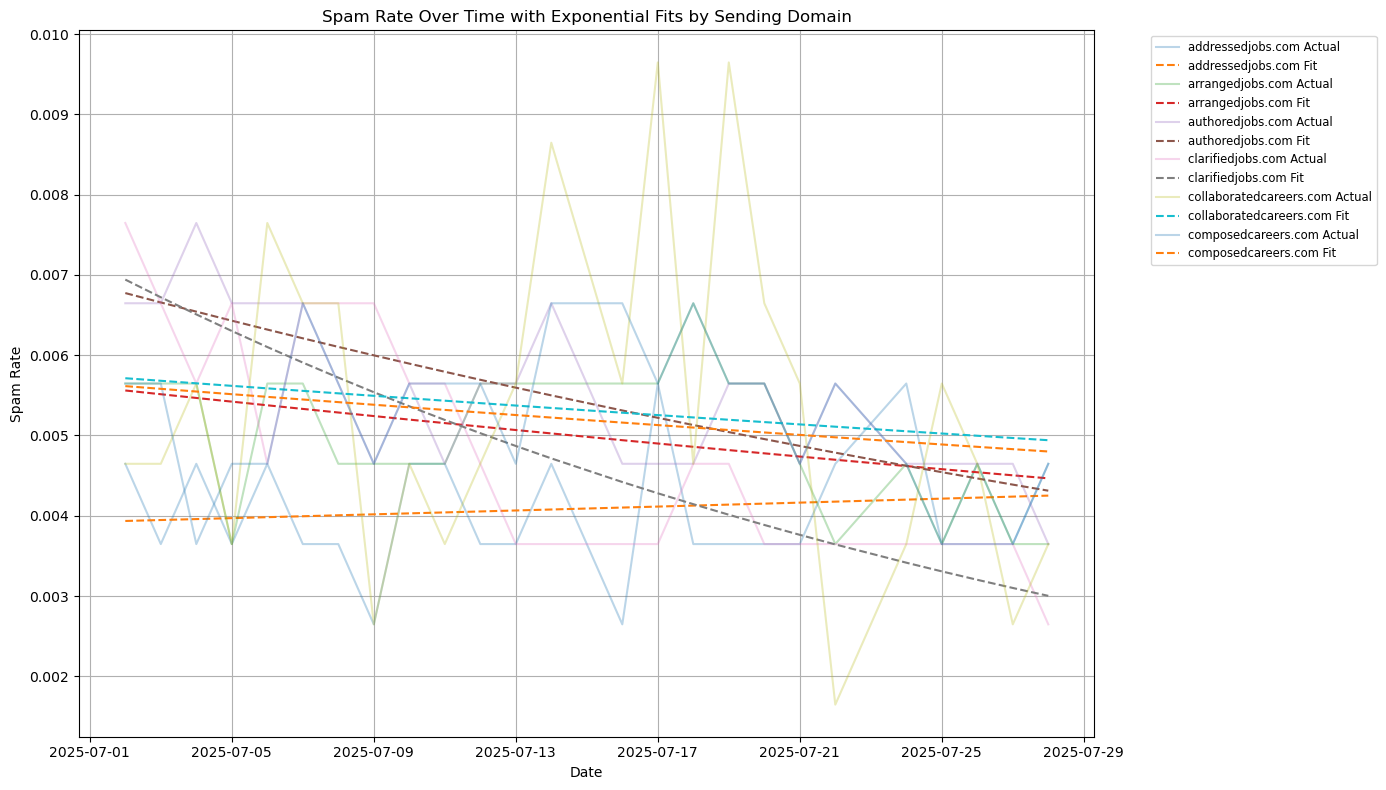

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load data
df = pd.read_csv("aws.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Convert dates to numeric values for fitting
df['DateOrdinal'] = df['Date'].map(pd.Timestamp.toordinal)

# Exponential model: y = a * exp(b * x)
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Set up the plot
plt.figure(figsize=(14, 8))

# Loop through each Sending Domain
for domain, group in df.groupby('Sending Domain'):
    # Sort by date
    group = group.sort_values('Date')
    
    x = group['DateOrdinal'].values
    y = group['Spam Rate'].values

    # Skip if not enough data or all zero
    if len(x) < 3 or np.all(y == 0):
        continue

    # Normalize x for better fitting stability
    x_norm = x - x.min()

    # Fit exponential
    try:
        popt, _ = curve_fit(exp_func, x_norm, y, maxfev=10000)
        y_fit = exp_func(x_norm, *popt)
    except RuntimeError:
        continue  # Skip domains where fit fails

    # Plot actual data
    plt.plot(group['Date'], y, label=f"{domain} Actual", alpha=0.3)

    # Plot exponential fit
    plt.plot(group['Date'], y_fit, linestyle='--', label=f"{domain} Fit")

plt.title("Spam Rate Over Time with Exponential Fits by Sending Domain")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\jthomas\AppData\Local\Temp\ipykernel_6176\726574112.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


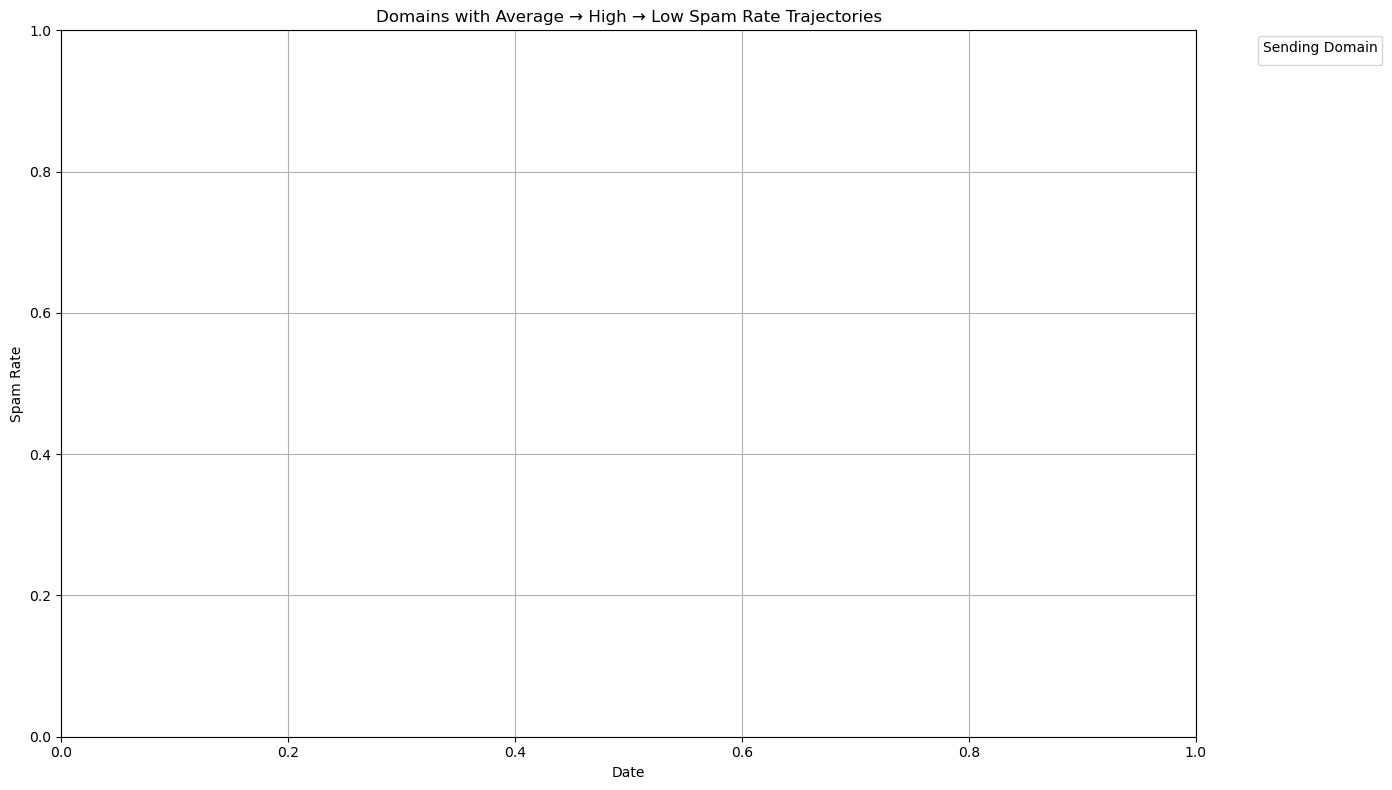

Matched Domains:


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv("aws.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['DateOrdinal'] = df['Date'].map(pd.Timestamp.toordinal)

# Plot setup
plt.figure(figsize=(14, 8))
matched_domains = []

# Loop through each domain
for domain, group in df.groupby('Sending Domain'):
    group = group.sort_values('Date')
    y = group['Spam Rate'].values
    x = group['Date'].values

    if len(y) < 5:
        continue

    # Basic 3-point pattern check
    start, peak, end = y[0], np.max(y), y[-1]

    # Define thresholds (tunable)
    if (
        start > 0.2 and start < 0.6 and   # average start
        peak > 0.8 and                   # high peak
        end < 0.2 and                    # low end
        np.argmax(y) > 0 and np.argmax(y) < len(y) - 1  # peak isn't at edge
    ):
        matched_domains.append(domain)
        plt.plot(x, y, label=domain, linewidth=2, alpha=0.8)

# Final touches
plt.title("Domains with Average → High → Low Spam Rate Trajectories")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: print matched domains
print("Matched Domains:")
for domain in matched_domains:
    print("-", domain)


addressedjobs.com: start=0.00, peak=0.01 (idx 14), end=0.00
arrangedjobs.com: start=0.01, peak=0.01 (idx 15), end=0.00
authoredjobs.com: start=0.01, peak=0.01 (idx 2), end=0.00
clarifiedjobs.com: start=0.01, peak=0.01 (idx 0), end=0.00
collaboratedcareers.com: start=0.00, peak=0.01 (idx 14), end=0.00
composedcareers.com: start=0.01, peak=0.01 (idx 5), end=0.00


C:\Users\jthomas\AppData\Local\Temp\ipykernel_6176\308338487.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


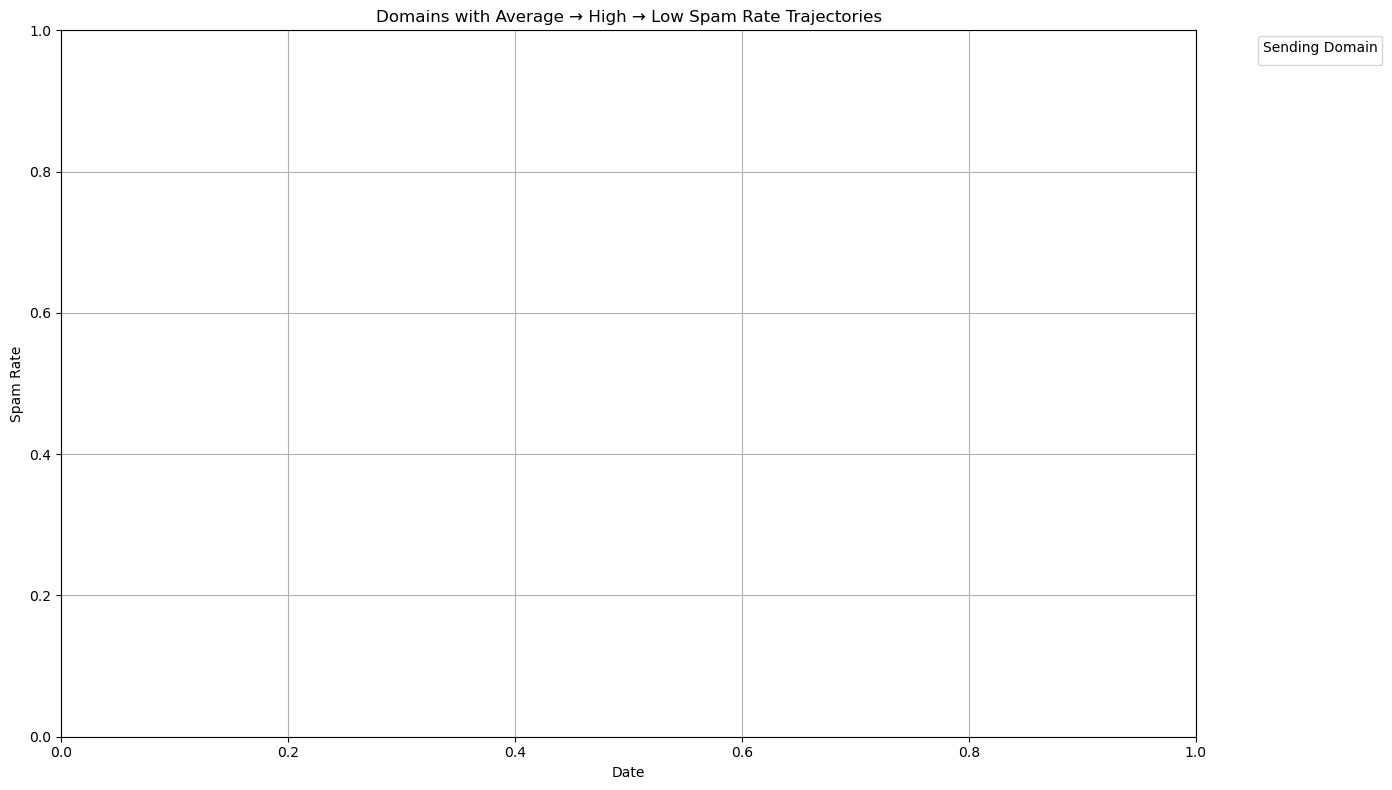


Matched domains:
No matches found. Consider loosening thresholds.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv("aws.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Sort to ensure chronological order
df = df.sort_values(['Sending Domain', 'Date'])

# Start the plot
plt.figure(figsize=(14, 8))
matched_domains = []

# Loop through each domain
for domain, group in df.groupby('Sending Domain'):
    y = group['Spam Rate'].values
    x = group['Date'].values

    if len(y) < 5:
        continue

    start = y[0]
    peak = np.max(y)
    end = y[-1]
    peak_idx = np.argmax(y)

    # Debug print for inspection
    print(f"{domain}: start={start:.2f}, peak={peak:.2f} (idx {peak_idx}), end={end:.2f}")

    # Relaxed thresholds
    if (
        0.1 <= start <= 0.7 and
        peak >= 0.8 and
        end <= 0.3 and
        0 < peak_idx < len(y) - 1
    ):
        matched_domains.append(domain)
        plt.plot(x, y, label=domain, linewidth=2)

# Finalize plot
plt.title("Domains with Average → High → Low Spam Rate Trajectories")
plt.xlabel("Date")
plt.ylabel("Spam Rate")
plt.legend(title="Sending Domain", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# Output matched domains
print("\nMatched domains:")
if matched_domains:
    for d in matched_domains:
        print(" -", d)
else:
    print("No matches found. Consider loosening thresholds.")


In [18]:
#!/usr/bin/env python3
"""
Republic Portfolio Tracker
===========================
Models the Republic Portfolio against SPY benchmark.
Fetches current and historical prices for holdings and aggregate portfolio.

Based on the Committee of Patriots Initial Holdings Session (December 2025)
"""

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import Optional, Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')


class RepublicPortfolio:
    """
    The Republic Portfolio as defined by the Committee of Patriots.
    
    Allocation Framework:
    - Engines of the Republic: 50%
    - Critical Choke Points: 35%
    - Reserve: 15%
    """
    
    # Portfolio structure with categories, holdings, and weights
    PORTFOLIO_STRUCTURE = {
        "Engines of the Republic": {
            "total_weight": 0.50,
            "categories": {
                "Manufacturing & Industry": {
                    "weight": 0.20,
                    "holdings": {
                        "CAT": "Caterpillar - Builds what builds America",
                        "DE": "Deere & Company - Food security through agricultural machinery",
                        "HON": "Honeywell - Industrial diversification, aerospace",
                        "LMT": "Lockheed Martin - Defense industrial base",
                        "GE": "GE Aerospace - Propulsion, power systems"
                    }
                },
                "Consumer & Retail": {
                    "weight": 0.12,
                    "holdings": {
                        "WMT": "Walmart - Where America shops",
                        "COST": "Costco - Model employer, shared prosperity",
                        "HD": "Home Depot - Housing maintenance, skilled trades"
                    }
                },
                "Healthcare Production": {
                    "weight": 0.06,
                    "holdings": {
                        "JNJ": "Johnson & Johnson - Pharmaceuticals, devices",
                        "PFE": "Pfizer - Manufacturing capacity, proven in crisis"
                    }
                },
                "Food & Agriculture": {
                    "weight": 0.07,
                    "holdings": {
                        "ADM": "Archer-Daniels-Midland - Grain processing",
                        "BG": "Bunge - Agricultural commodities",
                        "TSN": "Tyson Foods - Protein processing"
                    }
                },
                "Citizen Financial Access": {
                    "weight": 0.05,
                    "holdings": {
                        "SCHW": "Charles Schwab - Low-barrier brokerage",
                        "BRK-B": "Berkshire Hathaway - Patient capital"
                    }
                }
            }
        },
        "Critical Choke Points": {
            "total_weight": 0.35,
            "categories": {
                "Energy Infrastructure": {
                    "weight": 0.12,
                    "holdings": {
                        "NEE": "NextEra Energy - Largest utility, grid operator",
                        "D": "Dominion Energy - Eastern grid, nuclear capacity",
                        "KMI": "Kinder Morgan - Natural gas pipelines",
                        "WMB": "Williams Companies - Gas transmission"
                    }
                },
                "Financial Infrastructure": {
                    "weight": 0.08,
                    "holdings": {
                        "V": "Visa - Payment rails",
                        "MA": "Mastercard - Payment rails, duopoly",
                        "JPM": "JPMorgan Chase - Systemically important"
                    }
                },
                "Digital Infrastructure": {
                    "weight": 0.07,
                    "holdings": {
                        "MSFT": "Microsoft - Azure, enterprise backbone",
                        "AMZN": "Amazon - AWS, cloud infrastructure",
                        "GOOGL": "Alphabet - Cloud, search, digital cartography"
                    }
                },
                "Transportation Infrastructure": {
                    "weight": 0.05,
                    "holdings": {
                        "UNP": "Union Pacific - Western rail freight",
                        "NSC": "Norfolk Southern - Eastern rail freight"
                    }
                },
                "Healthcare Gatekeeping": {
                    "weight": 0.03,
                    "holdings": {
                        "MCK": "McKesson - Drug distribution",
                        "UNH": "UnitedHealth - Insurance/PBM gatekeeper (HOLD AS REFORMER)"
                    }
                }
            }
        },
        "Reserve": {
            "total_weight": 0.15,
            "categories": {
                "Cash & Treasuries": {
                    "weight": 0.15,
                    "holdings": {
                        "BIL": "SPDR Bloomberg 1-3 Month T-Bill ETF"
                    }
                }
            }
        }
    }
    
    def __init__(self, investment_amount: float = 5000.0):
        """
        Initialize the Republic Portfolio.
        
        Args:
            investment_amount: Total capital to allocate (default $5,000)
        """
        self.investment_amount = investment_amount
        self.holdings_weights = self._calculate_holding_weights()
        self.tickers = list(self.holdings_weights.keys())
        self._price_cache = {}
        
    def _calculate_holding_weights(self) -> Dict[str, float]:
        """Calculate the weight of each individual holding in the portfolio."""
        weights = {}
        
        for tier_name, tier_data in self.PORTFOLIO_STRUCTURE.items():
            for cat_name, cat_data in tier_data["categories"].items():
                cat_weight = cat_data["weight"]
                holdings = cat_data["holdings"]
                num_holdings = len(holdings)
                weight_per_holding = cat_weight / num_holdings
                
                for ticker in holdings.keys():
                    weights[ticker] = weight_per_holding
                    
        return weights
    
    def get_allocation(self) -> pd.DataFrame:
        """
        Get the dollar allocation for each holding based on investment amount.
        
        Returns:
            DataFrame with ticker, weight, and dollar allocation
        """
        data = []
        
        for tier_name, tier_data in self.PORTFOLIO_STRUCTURE.items():
            for cat_name, cat_data in tier_data["categories"].items():
                holdings = cat_data["holdings"]
                num_holdings = len(holdings)
                weight_per_holding = cat_data["weight"] / num_holdings
                
                for ticker, description in holdings.items():
                    allocation = self.investment_amount * weight_per_holding
                    data.append({
                        "Tier": tier_name,
                        "Category": cat_name,
                        "Ticker": ticker,
                        "Description": description.split(" - ")[0] if " - " in description else description,
                        "Weight": weight_per_holding,
                        "Allocation": allocation
                    })
        
        df = pd.DataFrame(data)
        return df
    
    def get_current_prices(self) -> pd.DataFrame:
        """
        Fetch current prices for all holdings.
        
        Returns:
            DataFrame with current price data
        """
        print("Fetching current prices...")
        data = []
        
        for ticker in self.tickers:
            try:
                stock = yf.Ticker(ticker)
                info = stock.info
                hist = stock.history(period="2d")
                
                if len(hist) > 0:
                    current_price = hist['Close'].iloc[-1]
                    prev_price = hist['Close'].iloc[0] if len(hist) > 1 else current_price
                    change = ((current_price - prev_price) / prev_price) * 100
                    
                    data.append({
                        "Ticker": ticker,
                        "Price": current_price,
                        "Change %": change,
                        "Weight": self.holdings_weights[ticker],
                        "Allocation": self.investment_amount * self.holdings_weights[ticker],
                        "Shares": (self.investment_amount * self.holdings_weights[ticker]) / current_price
                    })
            except Exception as e:
                print(f"  Warning: Could not fetch {ticker}: {e}")
                
        return pd.DataFrame(data)
    
    def get_historical_prices(
        self, 
        start_date: Optional[str] = None, 
        end_date: Optional[str] = None,
        period: str = "1y"
    ) -> pd.DataFrame:
        """
        Fetch historical prices for all holdings.
        
        Args:
            start_date: Start date (YYYY-MM-DD format)
            end_date: End date (YYYY-MM-DD format)  
            period: Alternative to dates - "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "max"
            
        Returns:
            DataFrame with historical adjusted close prices
        """
        print(f"Fetching historical prices...")
        
        if start_date and end_date:
            data = yf.download(self.tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
        else:
            data = yf.download(self.tickers, period=period, auto_adjust=True, progress=False)
        
        # Extract Close prices
        if isinstance(data.columns, pd.MultiIndex):
            prices = data['Close']
        else:
            prices = data[['Close']]
            prices.columns = self.tickers
            
        return prices
    
    def get_holding_history(
        self, 
        ticker: str, 
        period: str = "1y"
    ) -> pd.DataFrame:
        """
        Get detailed historical data for a single holding.
        
        Args:
            ticker: Stock ticker symbol
            period: Time period
            
        Returns:
            DataFrame with OHLCV data
        """
        if ticker not in self.tickers:
            raise ValueError(f"{ticker} is not in the Republic Portfolio")
            
        stock = yf.Ticker(ticker)
        hist = stock.history(period=period, auto_adjust=True)
        return hist
    
    def calculate_portfolio_value(
        self,
        start_date: Optional[str] = None,
        end_date: Optional[str] = None,
        period: str = "1y"
    ) -> pd.DataFrame:
        """
        Calculate the portfolio value over time.
        
        Args:
            start_date: Start date (YYYY-MM-DD)
            end_date: End date (YYYY-MM-DD)
            period: Alternative time period
            
        Returns:
            DataFrame with portfolio value over time
        """
        prices = self.get_historical_prices(start_date, end_date, period)
        
        # Calculate weighted returns
        weights = pd.Series(self.holdings_weights)
        
        # Normalize prices to start at 1
        normalized = prices / prices.iloc[0]
        
        # Calculate portfolio value (starting with investment amount)
        portfolio_value = (normalized * weights).sum(axis=1) * self.investment_amount
        
        return pd.DataFrame({
            "Portfolio Value": portfolio_value
        })
    
    def compare_to_benchmark(
        self,
        benchmark: str = "SPY",
        start_date: Optional[str] = None,
        end_date: Optional[str] = None,
        period: str = "1y"
    ) -> Tuple[pd.DataFrame, Dict]:
        """
        Compare portfolio performance to a benchmark (default SPY).
        
        Args:
            benchmark: Benchmark ticker (default SPY for S&P 500)
            start_date: Start date
            end_date: End date
            period: Time period
            
        Returns:
            Tuple of (DataFrame with comparison data, Dict with statistics)
        """
        print(f"Comparing Republic Portfolio to {benchmark}...")
        
        # Get portfolio holdings prices
        all_tickers = self.tickers + [benchmark]
        
        if start_date and end_date:
            data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
        else:
            data = yf.download(all_tickers, period=period, auto_adjust=True, progress=False)
        
        if isinstance(data.columns, pd.MultiIndex):
            prices = data['Close']
        else:
            prices = data
            
        # Separate benchmark
        benchmark_prices = prices[benchmark]
        portfolio_prices = prices.drop(columns=[benchmark])
        
        # Normalize to starting value
        benchmark_norm = benchmark_prices / benchmark_prices.iloc[0]
        portfolio_norm = portfolio_prices / portfolio_prices.iloc[0]
        
        # Calculate weighted portfolio
        weights = pd.Series(self.holdings_weights)
        weights = weights[portfolio_norm.columns]  # Align with available columns
        
        portfolio_weighted = (portfolio_norm * weights).sum(axis=1)
        
        # Scale to investment amount
        portfolio_value = portfolio_weighted * self.investment_amount
        benchmark_value = benchmark_norm * self.investment_amount
        
        # Create comparison DataFrame
        comparison = pd.DataFrame({
            "Republic Portfolio": portfolio_value,
            f"{benchmark}": benchmark_value,
            "Difference": portfolio_value - benchmark_value
        })
        
        # Calculate statistics
        trading_days = len(comparison)
        years = trading_days / 252
        
        # Total returns
        portfolio_return = (portfolio_value.iloc[-1] / self.investment_amount - 1) * 100
        benchmark_return = (benchmark_value.iloc[-1] / self.investment_amount - 1) * 100
        
        # CAGR
        portfolio_cagr = ((portfolio_value.iloc[-1] / self.investment_amount) ** (1/years) - 1) * 100 if years > 0 else 0
        benchmark_cagr = ((benchmark_value.iloc[-1] / self.investment_amount) ** (1/years) - 1) * 100 if years > 0 else 0
        
        # Daily returns for volatility
        portfolio_daily_returns = portfolio_value.pct_change().dropna()
        benchmark_daily_returns = benchmark_value.pct_change().dropna()
        
        # Annualized volatility
        portfolio_vol = portfolio_daily_returns.std() * np.sqrt(252) * 100
        benchmark_vol = benchmark_daily_returns.std() * np.sqrt(252) * 100
        
        # Max drawdown
        portfolio_peak = portfolio_value.expanding().max()
        portfolio_drawdown = ((portfolio_value - portfolio_peak) / portfolio_peak).min() * 100
        
        benchmark_peak = benchmark_value.expanding().max()
        benchmark_drawdown = ((benchmark_value - benchmark_peak) / benchmark_peak).min() * 100
        
        # Sharpe ratio (assuming 4% risk-free rate)
        rf_rate = 0.04
        portfolio_sharpe = (portfolio_cagr/100 - rf_rate) / (portfolio_vol/100) if portfolio_vol > 0 else 0
        benchmark_sharpe = (benchmark_cagr/100 - rf_rate) / (benchmark_vol/100) if benchmark_vol > 0 else 0
        
        # Beta
        covariance = portfolio_daily_returns.cov(benchmark_daily_returns)
        benchmark_variance = benchmark_daily_returns.var()
        beta = covariance / benchmark_variance if benchmark_variance > 0 else 1
        
        stats = {
            "Period": f"{comparison.index[0].strftime('%Y-%m-%d')} to {comparison.index[-1].strftime('%Y-%m-%d')}",
            "Trading Days": trading_days,
            "Years": round(years, 2),
            "Republic Portfolio": {
                "Final Value": round(portfolio_value.iloc[-1], 2),
                "Total Return %": round(portfolio_return, 2),
                "CAGR %": round(portfolio_cagr, 2),
                "Volatility %": round(portfolio_vol, 2),
                "Max Drawdown %": round(portfolio_drawdown, 2),
                "Sharpe Ratio": round(portfolio_sharpe, 3)
            },
            f"{benchmark}": {
                "Final Value": round(benchmark_value.iloc[-1], 2),
                "Total Return %": round(benchmark_return, 2),
                "CAGR %": round(benchmark_cagr, 2),
                "Volatility %": round(benchmark_vol, 2),
                "Max Drawdown %": round(benchmark_drawdown, 2),
                "Sharpe Ratio": round(benchmark_sharpe, 3)
            },
            "Relative": {
                "Active Return %": round(portfolio_return - benchmark_return, 2),
                "Active CAGR %": round(portfolio_cagr - benchmark_cagr, 2),
                "Beta vs Benchmark": round(beta, 3),
                "Excess Final Value": round(portfolio_value.iloc[-1] - benchmark_value.iloc[-1], 2)
            }
        }
        
        return comparison, stats
    
    def print_portfolio_summary(self):
        """Print a formatted summary of the portfolio structure."""
        print("\n" + "="*70)
        print("THE REPUBLIC PORTFOLIO")
        print("="*70)
        print(f"Total Investment: ${self.investment_amount:,.2f}")
        print("="*70)
        
        for tier_name, tier_data in self.PORTFOLIO_STRUCTURE.items():
            tier_amount = self.investment_amount * tier_data["total_weight"]
            print(f"\n{tier_name.upper()} ({tier_data['total_weight']*100:.0f}%) — ${tier_amount:,.2f}")
            print("-"*60)
            
            for cat_name, cat_data in tier_data["categories"].items():
                cat_amount = self.investment_amount * cat_data["weight"]
                holdings = cat_data["holdings"]
                per_holding = cat_amount / len(holdings)
                
                print(f"\n  {cat_name} ({cat_data['weight']*100:.0f}%) — ${cat_amount:,.2f}")
                for ticker, desc in holdings.items():
                    print(f"    {ticker:6s} ${per_holding:>8,.2f}  {desc[:45]}")
        
        print("\n" + "="*70)
        print("Own them. Vote them. Govern.")
        print("="*70 + "\n")
    
    def export_to_csv(self, filename: str = "republic_portfolio_allocation.csv"):
        """Export the portfolio allocation to CSV."""
        df = self.get_allocation()
        df.to_csv(filename, index=False)
        print(f"Portfolio exported to {filename}")
        return filename


def print_stats(stats: Dict):
    """Pretty print the comparison statistics."""
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)
    print(f"Period: {stats['Period']}")
    print(f"Trading Days: {stats['Trading Days']} ({stats['Years']} years)")
    print("-"*70)
    
    print(f"\n{'Metric':<25} {'Republic':>15} {'SPY':>15} {'Difference':>15}")
    print("-"*70)
    
    rp = stats["Republic Portfolio"]
    spy = stats.get("SPY", stats.get(list(stats.keys())[4]))  # Handle different benchmark names
    rel = stats["Relative"]
    
    print(f"{'Final Value':<25} ${rp['Final Value']:>13,.2f} ${spy['Final Value']:>13,.2f} ${rel['Excess Final Value']:>13,.2f}")
    print(f"{'Total Return':<25} {rp['Total Return %']:>14.2f}% {spy['Total Return %']:>14.2f}% {rel['Active Return %']:>14.2f}%")
    print(f"{'CAGR':<25} {rp['CAGR %']:>14.2f}% {spy['CAGR %']:>14.2f}% {rel['Active CAGR %']:>14.2f}%")
    print(f"{'Volatility':<25} {rp['Volatility %']:>14.2f}% {spy['Volatility %']:>14.2f}%")
    print(f"{'Max Drawdown':<25} {rp['Max Drawdown %']:>14.2f}% {spy['Max Drawdown %']:>14.2f}%")
    print(f"{'Sharpe Ratio':<25} {rp['Sharpe Ratio']:>15.3f} {spy['Sharpe Ratio']:>15.3f}")
    print(f"{'Beta vs Benchmark':<25} {rel['Beta vs Benchmark']:>15.3f}")
    print("="*70 + "\n")


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":
    # Initialize portfolio with $5,000
    portfolio = RepublicPortfolio(investment_amount=5000)
    
    # Print portfolio structure
    portfolio.print_portfolio_summary()
    
    # Get current prices and allocations
    print("\nFetching current market data...")
    current = portfolio.get_current_prices()
    print("\nCurrent Holdings:")
    print(current.to_string(index=False))
    
    # Compare to SPY benchmark (1 year)
    print("\n" + "-"*70)
    comparison, stats = portfolio.compare_to_benchmark(period="1y")
    print_stats(stats)
    
    # Show a specific holding's history
    print("\nExample: CAT (Caterpillar) - Last 30 days")
    cat_hist = portfolio.get_holding_history("CAT", period="1mo")
    print(cat_hist.tail(10))
    
    # Export allocation to CSV
    portfolio.export_to_csv("republic_portfolio_allocation.csv")


THE REPUBLIC PORTFOLIO
Total Investment: $5,000.00

ENGINES OF THE REPUBLIC (50%) — $2,500.00
------------------------------------------------------------

  Manufacturing & Industry (20%) — $1,000.00
    CAT    $  200.00  Caterpillar - Builds what builds America
    DE     $  200.00  Deere & Company - Food security through agric
    HON    $  200.00  Honeywell - Industrial diversification, aeros
    LMT    $  200.00  Lockheed Martin - Defense industrial base
    GE     $  200.00  GE Aerospace - Propulsion, power systems

  Consumer & Retail (12%) — $600.00
    WMT    $  200.00  Walmart - Where America shops
    COST   $  200.00  Costco - Model employer, shared prosperity
    HD     $  200.00  Home Depot - Housing maintenance, skilled tra

  Healthcare Production (6%) — $300.00
    JNJ    $  150.00  Johnson & Johnson - Pharmaceuticals, devices
    PFE    $  150.00  Pfizer - Manufacturing capacity, proven in cr

  Food & Agriculture (7%) — $350.00
    ADM    $  116.67  Archer-Daniels-M